## 0 · Imports & global style

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BLUE  = '#185FA5'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
RED   = '#C0392B'
GRAY  = '#888780'

OUT_DIR = Path('output_figures')
OUT_DIR.mkdir(exist_ok=True)
print('Output dir:', OUT_DIR.resolve())

Output dir: B:\School\Masterproef\All_usefull_code\analysis\output_figures


## 1 · Exponential growth of reported nests in Belgium

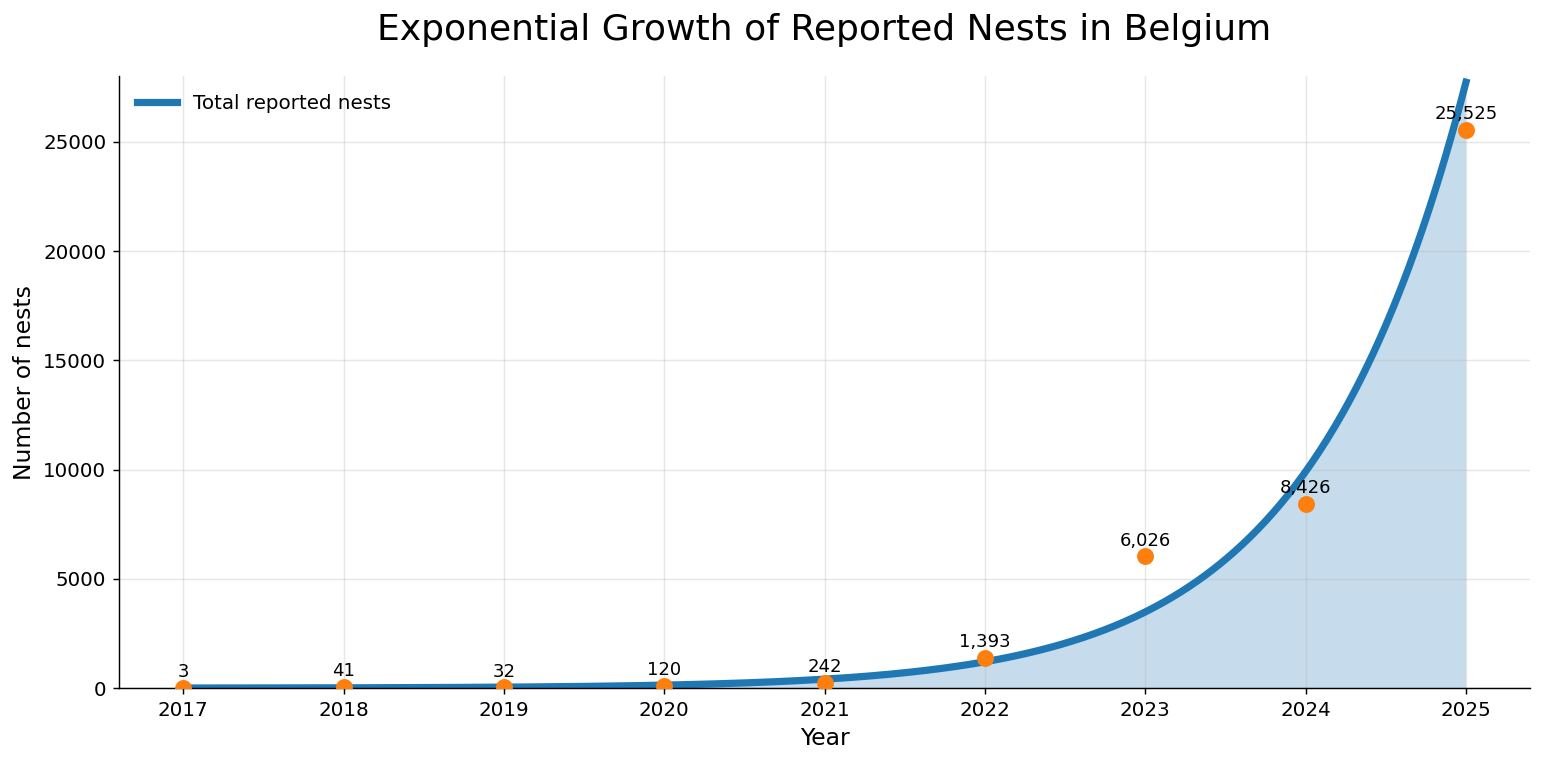

In [9]:
# -----------------------------
# Total data only
# -----------------------------
years = np.array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
totals = np.array([3, 41, 32, 120, 242, 1393, 6026, 8426, 25525])

# -----------------------------
# Smooth exponential-style fit
# -----------------------------
coeffs = np.polyfit(years, np.log(totals), 2)

x_smooth = np.linspace(years.min(), years.max(), 500)
y_smooth = np.exp(np.polyval(coeffs, x_smooth))

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 1)

ax = fig.add_subplot(gs[0])

# Area fill for dramatic effect
ax.fill_between(
    x_smooth,
    y_smooth,
    alpha=0.25
)

# Smooth curve
ax.plot(
    x_smooth,
    y_smooth,
    linewidth=4,
    label="Total reported nests"
)

# Original data points
ax.scatter(
    years,
    totals,
    s=70,
    zorder=3
)

# -----------------------------
# Styling
# -----------------------------
ax.set_title(
    "Exponential Growth of Reported Nests in Belgium",
    fontsize=20,
    pad=20
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of nests", fontsize=13)

# Non-log scale to emphasize explosive growth
ax.set_ylim(0, 28000)

# Clean ticks
ax.set_xticks(years)

# Add value labels
for x, y in zip(years, totals):
    ax.text(
        x,
        y + 500,
        f"{y:,}",
        ha='center',
        fontsize=10
    )

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 2 · Detection performance by training run  (`model_ranking.csv`)

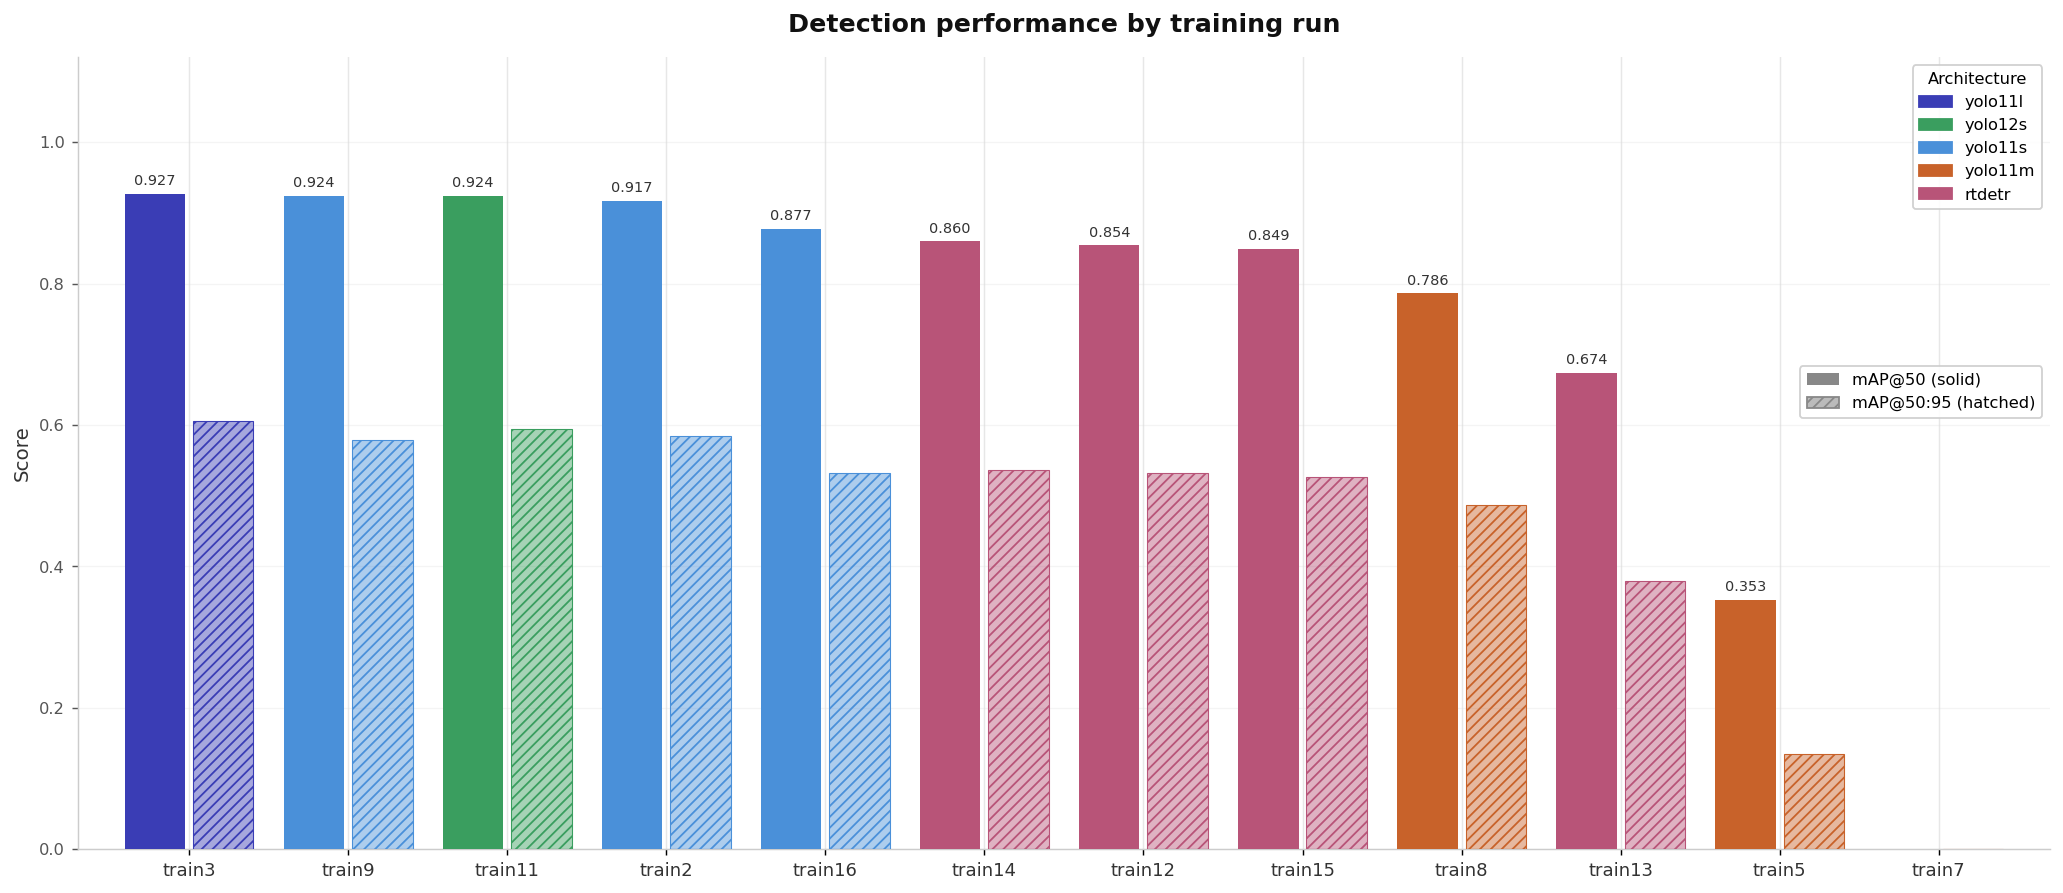

Saved → detection_performance.png


In [10]:
# ── Load ───────────────────────────────────────────────────────────────────────
df_model_ranking = pd.read_csv("./csv/model_ranking.csv")
df_model_ranking["metric_map50-95"] = pd.to_numeric(df_model_ranking["metric_map50-95"], errors="coerce").fillna(0)
df_model_ranking = df_model_ranking.sort_values("metric_map50", ascending=False)

# ── Architecture mapping ───────────────────────────────────────────────────────
arch_map = {
    "yolo11l.pt": "yolo11l",
    "yolo12s.pt": "yolo12s",
    "yolo11s.pt": "yolo11s",
    "yolo11m.pt": "yolo11m",
    "rtdetr-l.pt": "rtdetr",
}
color_map = {
    "yolo11l": "#3a3db5",   # deep indigo
    "yolo12s": "#3a9e5f",   # green
    "yolo11s": "#4a90d9",   # steel blue
    "yolo11m": "#c8622a",   # burnt orange
    "rtdetr":  "#b85478",   # muted rose
}

df_model_ranking["arch"] = df_model_ranking["model"].map(arch_map)
df_model_ranking["color"] = df_model_ranking["arch"].map(color_map)

# ── Plot setup ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

n = len(df_model_ranking)
x = np.arange(n)
bar_w = 0.38
gap = 0.05

bars1 = []
bars2 = []

for i, (_, row) in enumerate(df_model_ranking.iterrows()):
    col = row["color"]

    # Solid bar – mAP@50
    b1 = ax.bar(x[i] - bar_w/2 - gap/2, row["metric_map50"],
                width=bar_w, color=col, zorder=3)
    bars1.append(b1)

    # Hatched bar – mAP@50:95 (lighter fill + hatch)
    light = (*plt.matplotlib.colors.to_rgb(col), 0.45)
    b2 = ax.bar(x[i] + bar_w/2 + gap/2, row["metric_map50-95"],
                width=bar_w, color=light, hatch="////",
                edgecolor=col, linewidth=0.6, zorder=3)
    bars2.append(b2)

    # Value label above solid bar (skip 0)
    if row["metric_map50"] > 0:
        ax.text(x[i] - bar_w/2 - gap/2, row["metric_map50"] + 0.008,
                f"{row['metric_map50']:.3f}", ha="center", va="bottom",
                fontsize=8, color="#333333")

# ── Axes styling ───────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(df_model_ranking["run_name"], fontsize=10, color="#333333")
ax.set_ylabel("Score", fontsize=11, color="#333333")
ax.set_title("Detection performance by training run",
             fontsize=14, fontweight="bold", color="#111111", pad=14)
ax.set_ylim(0, 1.12)
ax.yaxis.set_tick_params(labelsize=9, colors="#555555")
ax.set_xlim(-0.7, n - 0.3)

ax.grid(axis="y", color="#dddddd", linestyle="-", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")

# ── Legend: architectures ──────────────────────────────────────────────────────
arch_patches = [mpatches.Patch(color=color_map[a], label=a)
                for a in color_map]
leg1 = ax.legend(handles=arch_patches, title="Architecture",
                 loc="upper right", fontsize=9, title_fontsize=9,
                 framealpha=0.9, edgecolor="#cccccc",
                 bbox_to_anchor=(1.0, 1.0))
ax.add_artist(leg1)

# Second legend: solid vs hatched
solid_patch = mpatches.Patch(facecolor="#888888", label="mAP@50 (solid)")
hatch_patch = mpatches.Patch(facecolor="#bbbbbb", hatch="////",
                              edgecolor="#888888", label="mAP@50:95 (hatched)")
ax.legend(handles=[solid_patch, hatch_patch],
          loc="upper right", fontsize=9,
          framealpha=0.9, edgecolor="#cccccc",
          bbox_to_anchor=(1.0, 0.62))

plt.tight_layout()
plt.savefig("./output_figures/detection_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → detection_performance.png")

## 3 · TP / FP per confidence threshold  (`confidence_sweep_*.csv`)

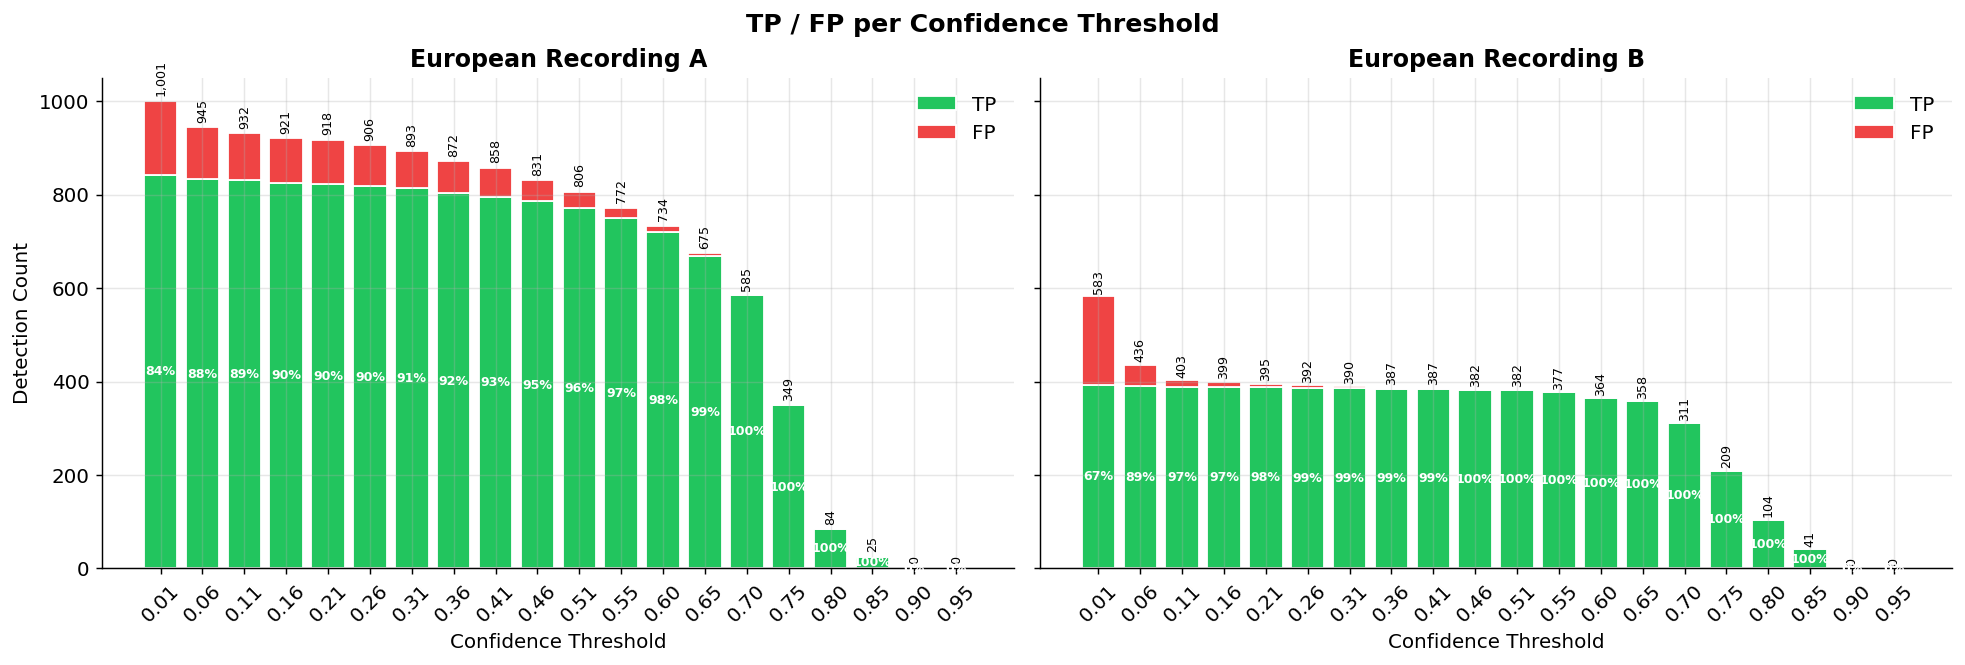

In [ ]:
# ---------------------------------------------------
# Load CSV files
# ---------------------------------------------------

df_conf_andere = pd.read_csv('./csv/confidence_sweep_andere_europe.csv')

df_conf_nieuw = pd.read_csv('./csv/confidence_sweep_neiuwe_europe.csv')

# ---------------------------------------------------
# Figure Setup
# ---------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    constrained_layout=True,
    sharey=True
)

datasets = [
    ("European Recording A", df_conf_andere),
    ("European Recording B", df_conf_nieuw),
]
# ---------------------------------------------------
# Plotting
# ---------------------------------------------------

for ax, (title, df) in zip(axes, datasets):

    x = np.arange(len(df))

    tp = df['correct']
    fp = df['wrong']

    # ---------------------------------------------------
    # STACKED BARS
    # ---------------------------------------------------

    bars_tp = ax.bar(
        x,
        tp,
        color='#22c55e',
        edgecolor='white',
        label='TP'
    )

    bars_fp = ax.bar(
        x,
        fp,
        bottom=tp,
        color='#ef4444',
        edgecolor='white',
        label='FP'
    )

    # ---------------------------------------------------
    # TOTAL LABELS
    # ---------------------------------------------------

    totals = tp + fp

    for i, total in enumerate(totals):

        ax.text(
            x[i],
            total + totals.max() * 0.01,
            f'{int(total):,}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=90
        )

    # ---------------------------------------------------
    # Accuracy labels inside TP region
    # ---------------------------------------------------

    for i, acc in enumerate(df['accuracy']):

        ax.text(
            x[i],
            tp.iloc[i] * 0.5,
            f'{acc:.0f}%',
            ha='center',
            va='center',
            fontsize=7,
            color='white',
            fontweight='bold'
        )

    # ---------------------------------------------------
    # Styling
    # ---------------------------------------------------

    ax.set_title(title, fontweight='bold')

    ax.set_xticks(x)

    ax.set_xticklabels(
        [f'{t:.2f}' for t in df['threshold']],
        rotation=45
    )

    ax.set_xlabel('Confidence Threshold')

    ax.legend(frameon=False)

# ---------------------------------------------------
# Labels
# ---------------------------------------------------

axes[0].set_ylabel('Detection Count')

fig.suptitle(
    'TP / FP per Confidence Threshold',
    fontsize=14,
    fontweight='bold'
)

plt.show()

## 4 · GMM comparison — half & full scale  (`gmm_met_half_en_met_en_zonder.csv`)

In [12]:
df_gmm_half = pd.read_csv('./csv/gmm_met_half_en_met_en_zonder.csv')

def label(row):
    status = "GMM" if row['use_gmm'] else "No GMM"
    scale  = f"scale={row['gmm_downscale']}"
    return f"{status}\n{scale}"

df_gmm_half['label'] = df_gmm_half.apply(label, axis=1)

GTs      = ['gt1', 'gt2', 'gt3']
GT_NAMES = ['GT1', 'GT2', 'GT3']
COLORS   = ['#2E86AB', '#E84855', '#3BB273']

x     = np.arange(len(df_gmm_half))
bar_w = 0.55

df_gmm_half[['trial', 'elapsed_s', 'use_gmm', 'gmm_downscale',
    'gt1_HOTA', 'gt1_MOTA', 'gt2_HOTA', 'gt2_MOTA',
    'gt3_HOTA', 'gt3_MOTA', 'avg_HOTA', 'avg_MOTA']]

,trial,elapsed_s,use_gmm,gmm_downscale,gt1_HOTA,gt1_MOTA,gt2_HOTA,gt2_MOTA,gt3_HOTA,gt3_MOTA,avg_HOTA,avg_MOTA
0,1,436.6,True,1.00,75.64,51.36,64.76,36.05,85.64,71.32,75.35,52.91
1,2,192.8,False,1.00,72.43,53.58,61.11,39.16,86.13,73.46,73.22,55.40
2,3,214.0,True,0.25,73.94,47.91,61.98,29.94,85.15,70.07,73.69,49.31
3,4,192.9,False,0.25,72.43,53.58,61.11,39.16,86.13,73.46,73.22,55.40
4,5,193.3,False,0.50,72.43,53.58,61.11,39.16,86.13,73.46,73.22,55.40
5,6,254.3,True,0.50,74.82,49.77,63.98,34.67,85.84,71.88,74.88,52.11


## 5 · Detection metrics per GT — scale = 0.5  (uses `df_gmm_half`)

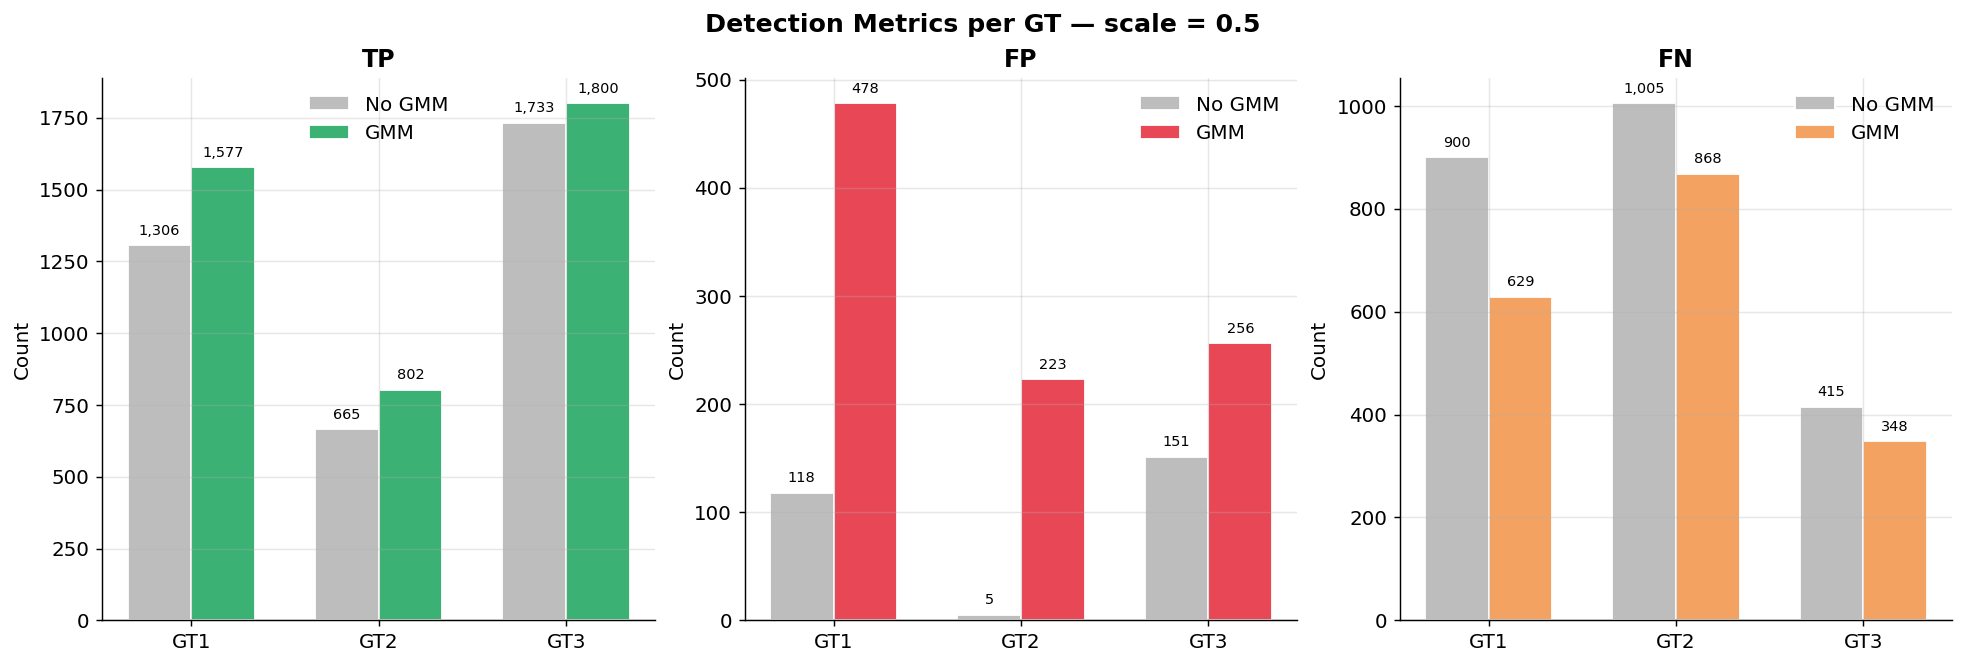

In [13]:
# ============================================================
# ALL DETECTION METRICS IN ONE FIGURE
# ONLY SCALE = 0.5
# IDS REMOVED
# ============================================================

df_half = df_gmm_half[df_gmm_half['gmm_downscale'] == 0.5].copy()

metrics = ['TP', 'FP', 'FN']
metric_colors = ['#3BB273', '#E84855', '#F4A261']

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    constrained_layout=True
)

fig.suptitle(
    'Detection Metrics per GT — scale = 0.5',
    fontsize=14,
    fontweight='bold'
)

x = np.arange(len(GTs))
w = 0.34

for ax, metric, col in zip(axes.flat, metrics, metric_colors):

    vals_no_gmm = []
    vals_gmm    = []

    for gt in GTs:

        no_gmm_row = df_half[df_half['use_gmm'] == False].iloc[0]
        gmm_row    = df_half[df_half['use_gmm'] == True].iloc[0]

        vals_no_gmm.append(no_gmm_row[f'{gt}_{metric}'])
        vals_gmm.append(gmm_row[f'{gt}_{metric}'])

    bars1 = ax.bar(
        x - w/2,
        vals_no_gmm,
        width=w,
        label='No GMM',
        color='#BDBDBD',
        edgecolor='white'
    )

    bars2 = ax.bar(
        x + w/2,
        vals_gmm,
        width=w,
        label='GMM',
        color=col,
        edgecolor='white'
    )

    # --------------------------------------------------------
    # value labels above bars
    # --------------------------------------------------------
    ymax = max(vals_no_gmm + vals_gmm)

    for bars in [bars1, bars2]:

        for bar in bars:

            h = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + ymax * 0.015,
                f'{int(h):,}',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(metric, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(GT_NAMES)

    ax.set_ylabel('Count')

    ax.legend(frameon=False)

plt.show()

## 6 · HOTA & MOTA per GT — scale = 0.5  (uses `df_gmm_half`)

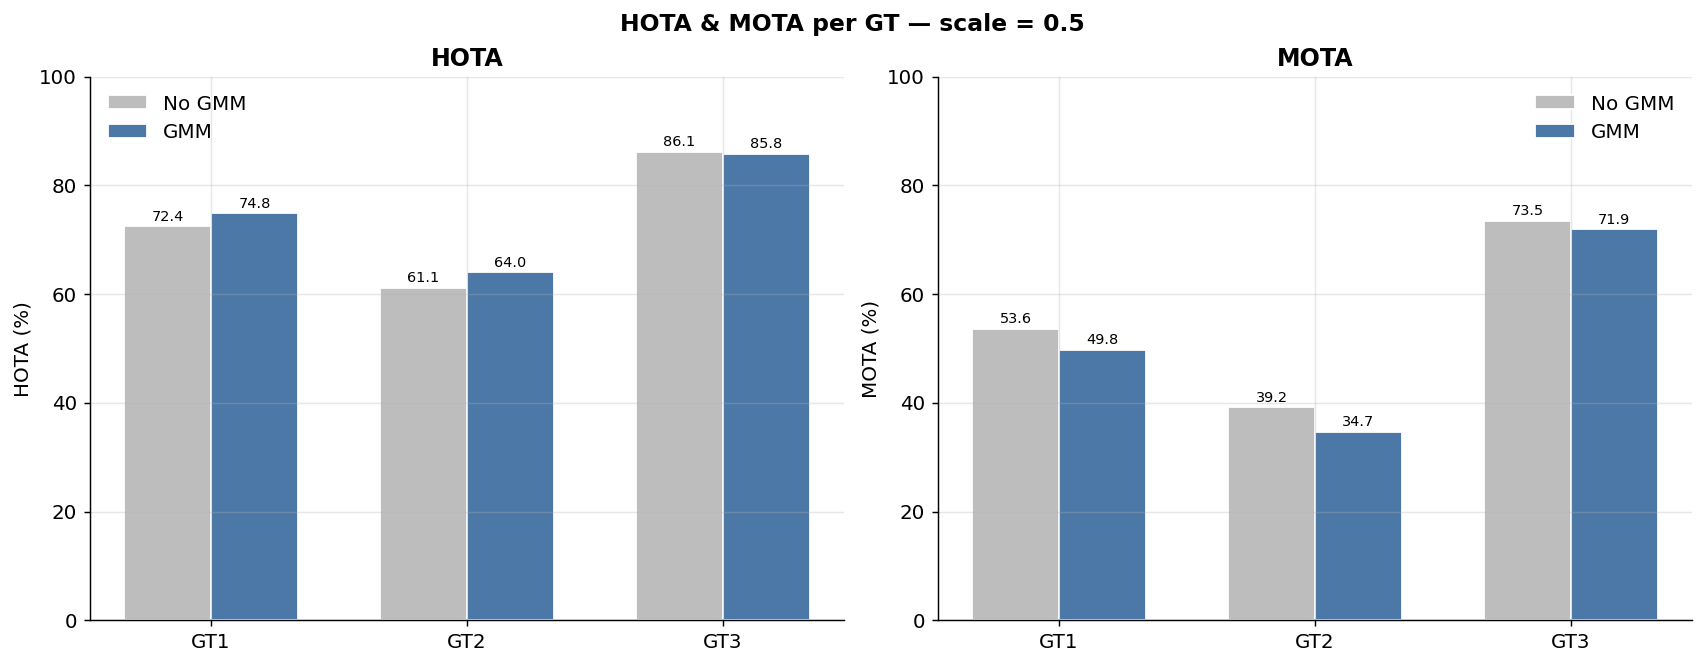

In [14]:
df_gmm_half_05 = df_gmm_half[df_gmm_half['gmm_downscale'] == 0.5].copy()

# ============================================================
# HOTA & MOTA
# ONLY SCALE = 0.5
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    constrained_layout=True
)

fig.suptitle(
    'HOTA & MOTA per GT — scale = 0.5',
    fontsize=13,
    fontweight='bold'
)

x = np.arange(len(GTs))
w = 0.34

for ax, metric in zip(axes, ['HOTA', 'MOTA']):

    vals_no_gmm = []
    vals_gmm    = []

    for gt in GTs:

        no_gmm_row = df_gmm_half_05[df_gmm_half_05['use_gmm'] == False].iloc[0]
        gmm_row    = df_gmm_half_05[df_gmm_half_05['use_gmm'] == True].iloc[0]

        vals_no_gmm.append(no_gmm_row[f'{gt}_{metric}'])
        vals_gmm.append(gmm_row[f'{gt}_{metric}'])

    bars1 = ax.bar(
        x - w/2,
        vals_no_gmm,
        width=w,
        label='No GMM',
        color='#BDBDBD',
        edgecolor='white'
    )

    bars2 = ax.bar(
        x + w/2,
        vals_gmm,
        width=w,
        label='GMM',
        color='#4C78A8',
        edgecolor='white'
    )

    # labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:

            h = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.5,
                f'{h:.1f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(metric, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(GT_NAMES)

    ax.set_ylabel(f'{metric} (%)')

    ax.set_ylim(0, 100)

    ax.legend(frameon=False)

plt.show()


## 7 · Processing time & average HOTA vs downscale  (uses `df_gmm_half`)

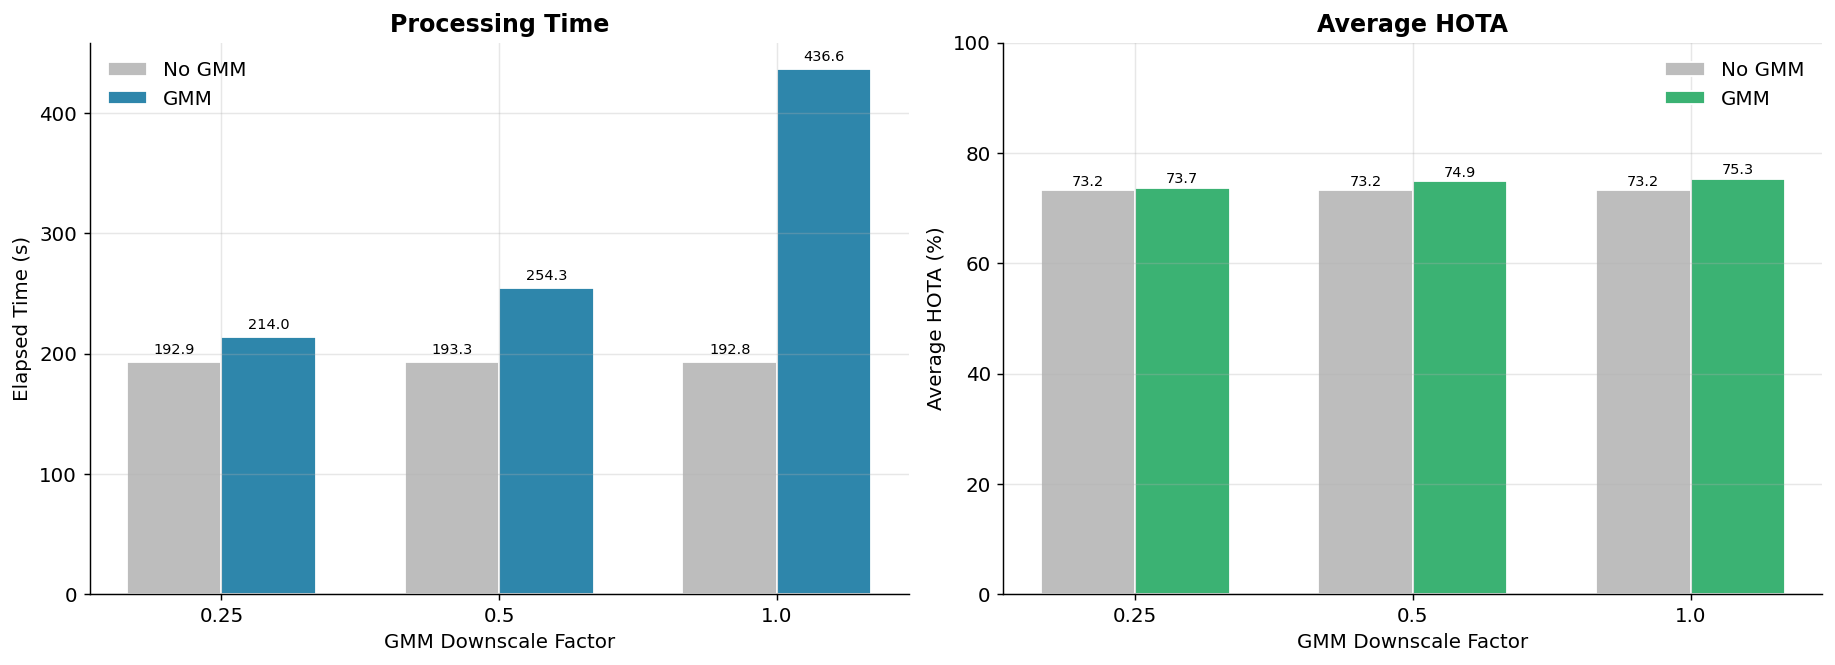

In [15]:
# ============================================================
# BAR PLOTS:
# 1. Processing Time vs Downscale
# 2. Average HOTA vs Downscale
# WITH vs WITHOUT GMM
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    constrained_layout=True
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

downscales = sorted(df_gmm_half['gmm_downscale'].unique())
x = np.arange(len(downscales))
w = 0.34

# ============================================================
# 1) PROCESSING TIME
# ============================================================

ax = axes[0]

vals_gmm = []
vals_no  = []

for scale in downscales:

    gmm_row = df_gmm_half[
        (df_gmm_half['gmm_downscale'] == scale) &
        (df_gmm_half['use_gmm'] == True)
    ].iloc[0]

    no_row = df_gmm_half[
        (df_gmm_half['gmm_downscale'] == scale) &
        (df_gmm_half['use_gmm'] == False)
    ].iloc[0]

    vals_gmm.append(gmm_row['elapsed_s'])
    vals_no.append(no_row['elapsed_s'])

bars1 = ax.bar(
    x - w/2,
    vals_no,
    width=w,
    label='No GMM',
    color='#BDBDBD',
    edgecolor='white'
)

bars2 = ax.bar(
    x + w/2,
    vals_gmm,
    width=w,
    label='GMM',
    color='#2E86AB',
    edgecolor='white'
)

# value labels
for bars in [bars1, bars2]:

    for bar in bars:

        h = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + max(vals_gmm + vals_no) * 0.01,
            f'{h:.1f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_title('Processing Time', fontweight='bold')
ax.set_xlabel('GMM Downscale Factor')
ax.set_ylabel('Elapsed Time (s)')
ax.set_xticks(x)
ax.set_xticklabels(downscales)
ax.legend(frameon=False)

# ============================================================
# 2) AVERAGE HOTA
# ============================================================

ax = axes[1]

vals_gmm = []
vals_no  = []

for scale in downscales:

    gmm_row = df_gmm_half[
        (df_gmm_half['gmm_downscale'] == scale) &
        (df_gmm_half['use_gmm'] == True)
    ].iloc[0]

    no_row = df_gmm_half[
        (df_gmm_half['gmm_downscale'] == scale) &
        (df_gmm_half['use_gmm'] == False)
    ].iloc[0]

    vals_gmm.append(gmm_row['avg_HOTA'])
    vals_no.append(no_row['avg_HOTA'])

bars1 = ax.bar(
    x - w/2,
    vals_no,
    width=w,
    label='No GMM',
    color='#BDBDBD',
    edgecolor='white'
)

bars2 = ax.bar(
    x + w/2,
    vals_gmm,
    width=w,
    label='GMM',
    color='#3BB273',
    edgecolor='white'
)

# value labels
for bars in [bars1, bars2]:

    for bar in bars:

        h = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.3,
            f'{h:.1f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_title('Average HOTA', fontweight='bold')
ax.set_xlabel('GMM Downscale Factor')
ax.set_ylabel('Average HOTA (%)')
ax.set_xticks(x)
ax.set_xticklabels(downscales)
ax.set_ylim(0, 100)
ax.legend(frameon=False)

plt.show()

## 8 · Nest vector angle evaluation  (`weighted_eval_results.csv`)

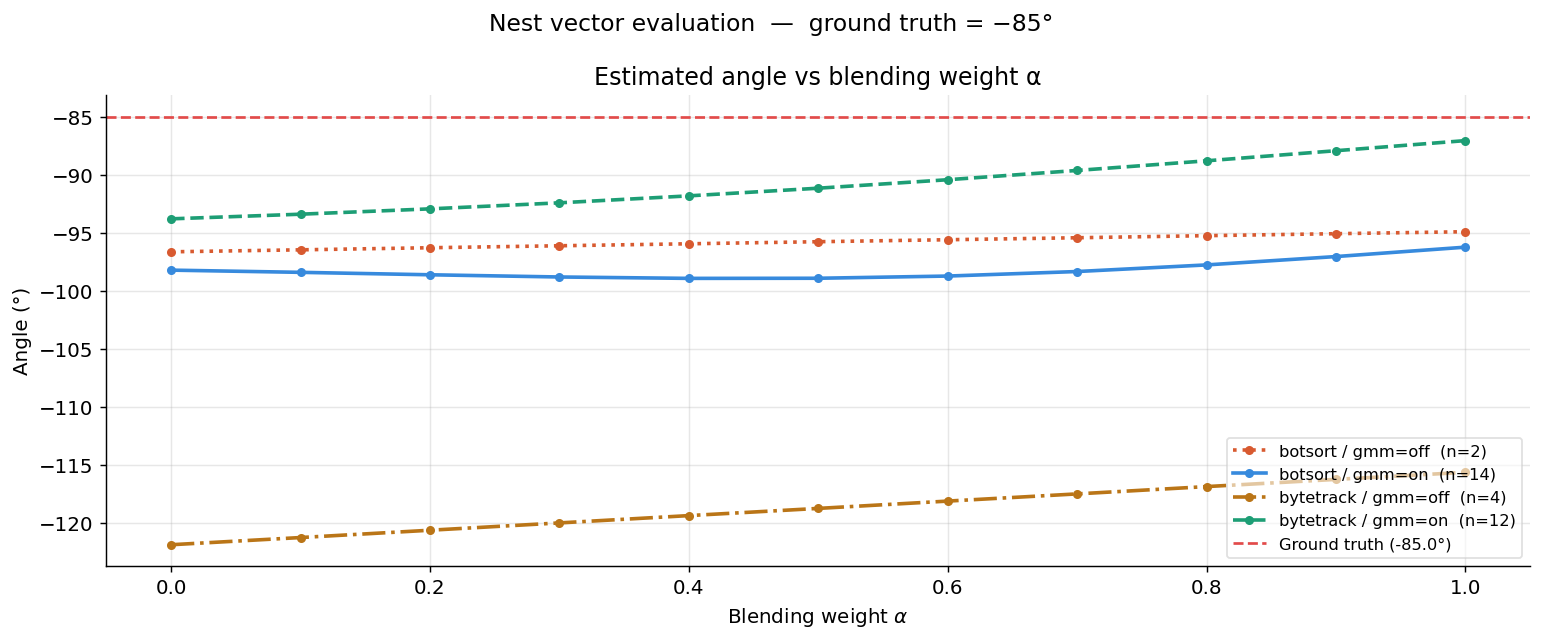

In [17]:
# ── Ground truth ──────────────────────────────────────────────────────────────
GROUND_TRUTH_DEG = -85.0

# ── Visual style ─────────────────────────────────────────────────────────────
COLORS = {
    ('botsort_hornet',  'on'):  '#378ADD',
    ('bytetrack_hornet','on'):  '#1D9E75',
    ('botsort_hornet',  'off'): '#D85A30',
    ('bytetrack_hornet','off'): '#BA7517',
}
LINESTYLES = {
    ('botsort_hornet',  'on'):  '-',
    ('bytetrack_hornet','on'):  '--',
    ('botsort_hornet',  'off'): ':',
    ('bytetrack_hornet','off'): '-.',
}
GT_COLOR   = '#E24B4A'
GT_LABEL   = f'Ground truth ({GROUND_TRUTH_DEG}°)'

df_weighted_eval = pd.read_csv('./csv/weighted_eval_results.csv')

fig, ax_angle = plt.subplots(figsize=(12, 5))

# ── Shared legend handles ────────────────────────────────────────────────────
handles, labels = [], []

for (tracker, gmm), grp in df_weighted_eval.groupby(['tracker', 'gmm']):
    key   = (tracker, gmm)
    color = COLORS[key]
    ls    = LINESTYLES[key]

    # α terminology
    label = f"{tracker.split('_')[0]} / gmm={gmm}  (n={grp['n'].iloc[0]})"

    w = grp['weight']

    # ── Angle plot ───────────────────────────────────────────────────────────
    line, = ax_angle.plot(
        w,
        grp['angle_deg'],
        color=color,
        ls=ls,
        lw=2,
        marker='o',
        ms=4,
        label=label
    )

    handles.append(line)
    labels.append(label)

# ── Ground truth reference ───────────────────────────────────────────────────
ax_angle.axhline(
    GROUND_TRUTH_DEG,
    color=GT_COLOR,
    lw=1.5,
    ls='--',
    label=GT_LABEL
)

# ── Labels ───────────────────────────────────────────────────────────────────
ax_angle.set_title(
    'Estimated angle vs blending weight α',
    fontweight='normal'
)

ax_angle.set_xlabel(r'Blending weight $\alpha$')
ax_angle.set_ylabel('Angle (°)')

# ── Legend ───────────────────────────────────────────────────────────────────
gt_handle = plt.Line2D(
    [0], [0],
    color=GT_COLOR,
    lw=1.5,
    ls='--',
    label=GT_LABEL
)

handles.append(gt_handle)
labels.append(GT_LABEL)

ax_angle.legend(
    handles,
    labels,
    loc='lower right',
    fontsize=9,
    framealpha=0.6,
    ncol=1
)

fig.suptitle(
    'Nest vector evaluation  —  ground truth = −85°',
    fontsize=13
)

plt.tight_layout()
plt.savefig('./output_figures/nest_vector_angle_only.png', bbox_inches='tight')
plt.show()

## 9 · GMM parameter sweep — setup  (`gmm.csv`)

In [18]:
df_gmm = pd.read_csv('./csv/gmm.csv')

SWEPT_PARAMS = [
    'lost_frames_before_gmm',
    'gmm_max_lost',
    'gmm_search_pad',
    'gmm_min_blob_area',
    'gmm_max_lifetime',
    'gmm_history',
    'gmm_var_threshold',
    'gmm_downscale',
    'relink_iou_thresh',
    'relink_dist_thresh',
    'iou_match_threshold'
]

# Which metrics to overlay on each subplot
METRICS = {
    'avg_HOTA':  ('HOTA',  '#2563eb'),   # blue
    'avg_MOTA':  ('MOTA',  '#16a34a'),   # green
    'avg_IDF1':  ('IDF1',  '#d97706'),   # amber
}

# GT-specific metrics for the per-sequence breakdown
GT_METRICS = {
    'HOTA': '#2563eb',
    'MOTA': '#16a34a',
    'MOTP': '#9333ea',
    'IDF1': '#d97706',
}
GT_NAMES = ['gt1', 'gt2', 'gt3']


def mean_by_param(df_gmm, param, metric):
    """Aggregate (mean ± std) metric over all trials that share the same param value."""
    g = df_gmm.groupby(param)[metric]
    return g.mean(), g.std().fillna(0)


print('Helper ready.')


Helper ready.


## 10 · GMM parameter heatmap  (uses `df_gmm`)

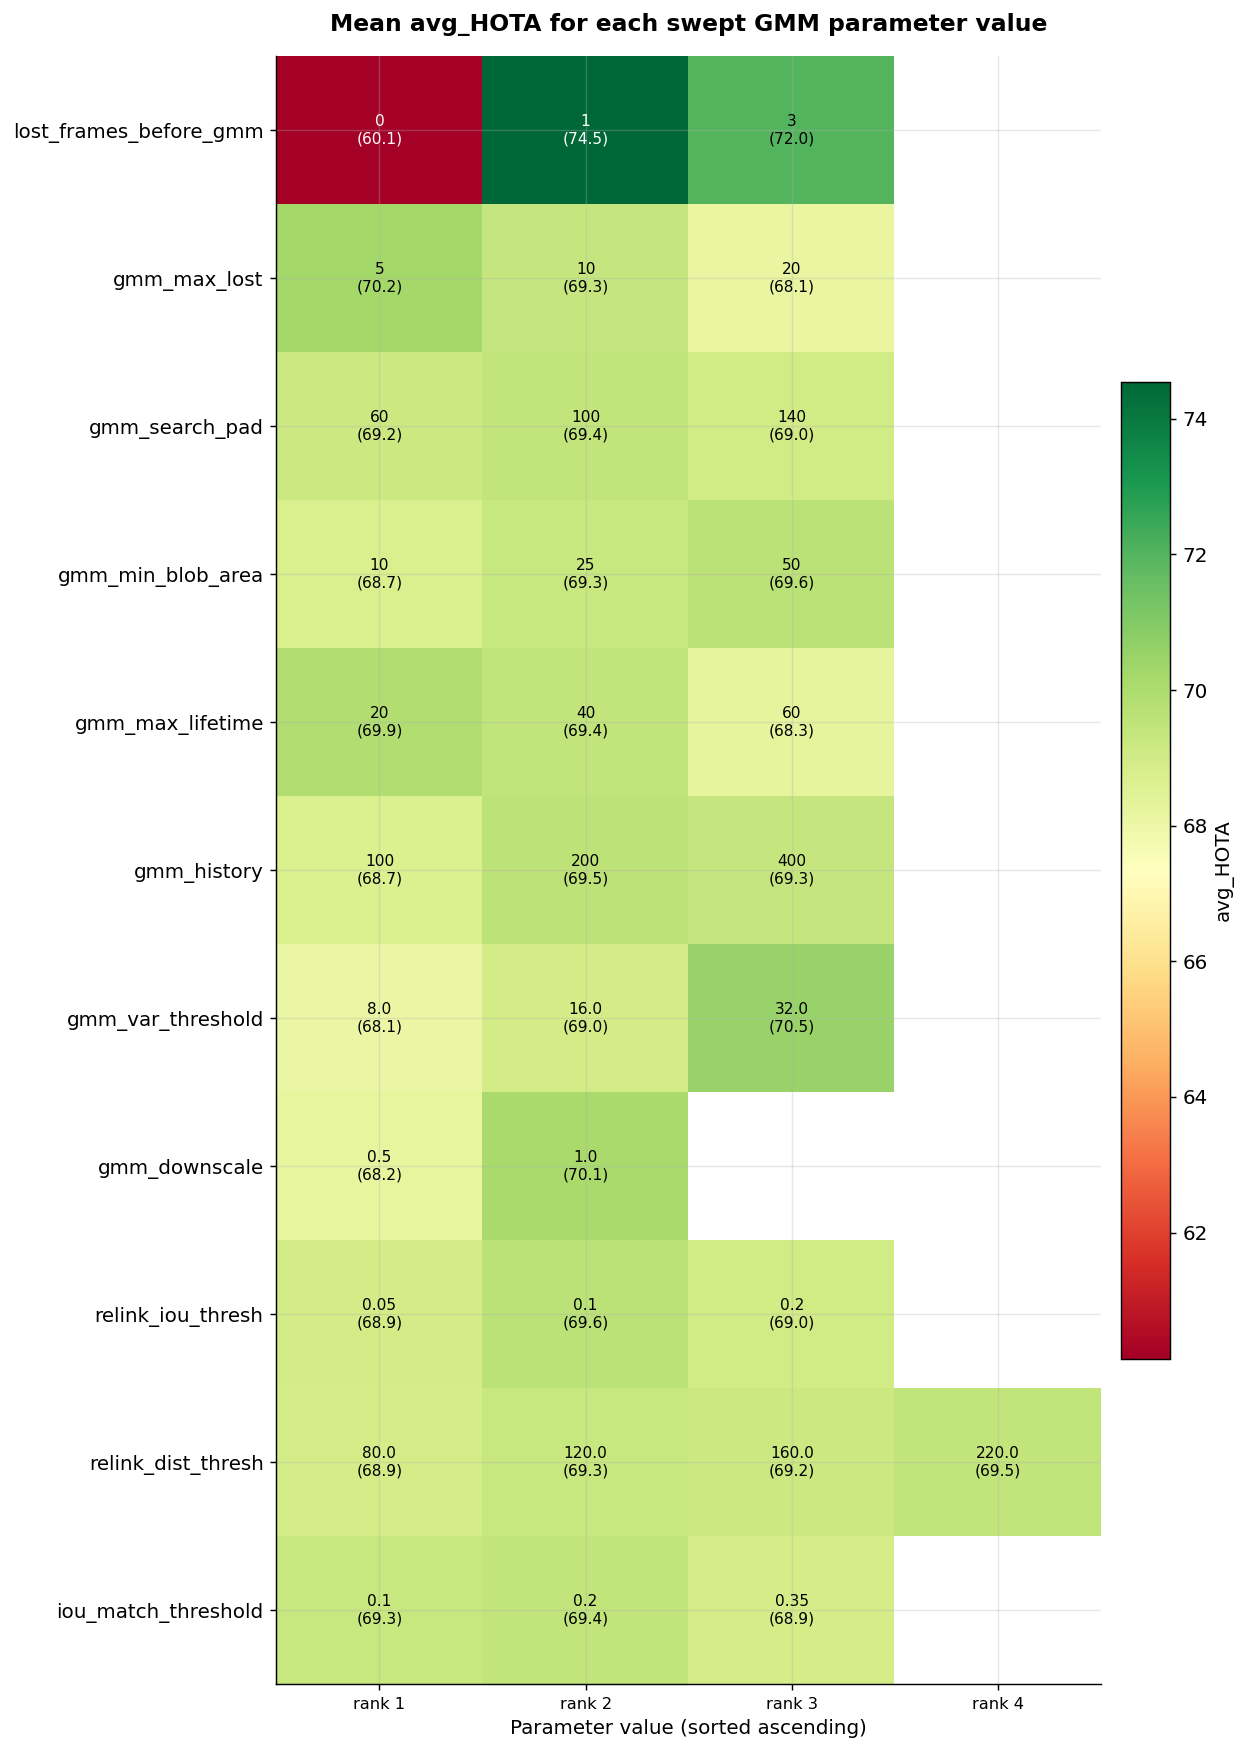

Saved → heatmap_single_gmm.png


In [20]:
heat_metric = 'avg_HOTA'   # ← change to 'avg_MOTA', 'avg_IDF1', etc.

# Build a matrix: mean metric value for every (param, param_value) combination
# Rows = parameters, Columns = their unique values (padded with NaN)
max_vals = max(df_gmm[p].nunique() for p in SWEPT_PARAMS)
matrix = np.full((len(SWEPT_PARAMS), max_vals), np.nan)

for i, param in enumerate(SWEPT_PARAMS):
    unique_vals = sorted(df_gmm[param].unique())
    means = df_gmm.groupby(param)[heat_metric].mean()
    for j, v in enumerate(unique_vals):
        matrix[i, j] = means.get(v, np.nan)

col_labels_per_param = {p: sorted(df_gmm[p].unique()) for p in SWEPT_PARAMS}

fig, ax = plt.subplots(figsize=(max(10, max_vals * 1.4), len(SWEPT_PARAMS) * 1.1 + 1.5))

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn',
               vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

for i, param in enumerate(SWEPT_PARAMS):
    vals = sorted(df_gmm[param].unique())
    for j, v in enumerate(vals):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f'{v}\n({matrix[i,j]:.1f})',
                    ha='center', va='center', fontsize=8.5,
                    color='black' if 0.35 < (matrix[i,j] - np.nanmin(matrix)) /
                    (np.nanmax(matrix) - np.nanmin(matrix) + 1e-9) < 0.85 else 'white')

ax.set_yticks(range(len(SWEPT_PARAMS)))
ax.set_yticklabels(SWEPT_PARAMS, fontsize=11)
ax.set_xticks(range(max_vals))
ax.set_xticklabels([f'rank {i+1}' for i in range(max_vals)], fontsize=9)
ax.set_xlabel('Parameter value (sorted ascending)', fontsize=11)
ax.set_title(f'Mean {heat_metric} for each swept GMM parameter value', fontsize=13, fontweight='bold', pad=14)

plt.colorbar(im, ax=ax, label=heat_metric, shrink=0.6, pad=0.02)
plt.tight_layout()
plt.savefig('./output_figures/heatmap_single_gmm.png', bbox_inches='tight')
plt.show()
print('Saved → heatmap_single_gmm.png')

## 11 · HOTA vs average vector angle error  (uses `df_gmm`)

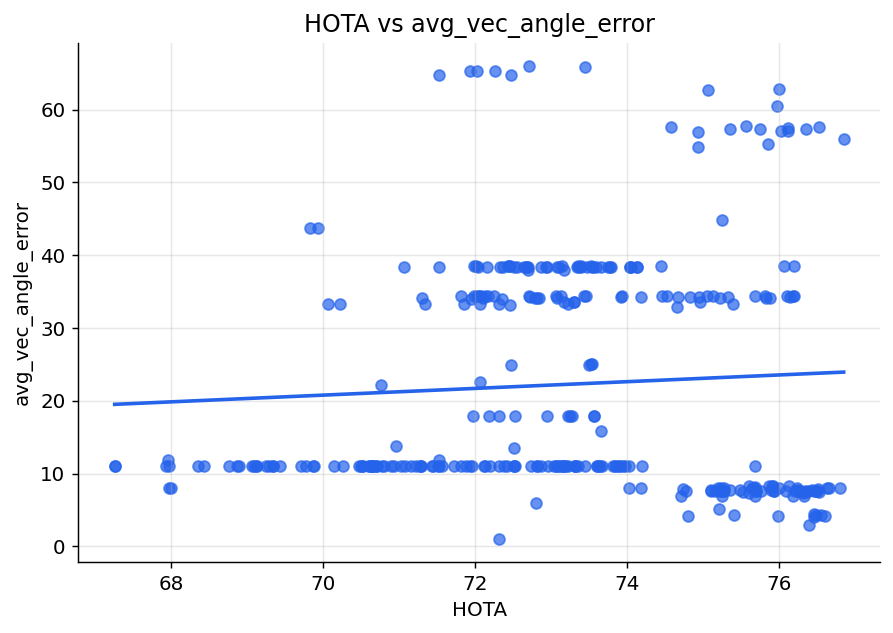

In [21]:
# Remove rows with missing values
plot_df = df_gmm[['avg_vec_angle_diff', 'avg_HOTA']].dropna()

# Apply threshold to HOTA
plot_df_hota = plot_df[plot_df['avg_HOTA'] >= 65]

# Single plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    plot_df_hota['avg_HOTA'],
    plot_df_hota['avg_vec_angle_diff'],
    alpha=0.7,
    color='#2563eb'
)

# Trend line
z = np.polyfit(plot_df_hota['avg_HOTA'], plot_df_hota['avg_vec_angle_diff'], 1)
p = np.poly1d(z)
x_vals = np.linspace(plot_df_hota['avg_HOTA'].min(), plot_df_hota['avg_HOTA'].max(), 100)
ax.plot(x_vals, p(x_vals), color='#2563eb', linewidth=2)

ax.set_title('HOTA vs avg_vec_angle_error')
ax.set_xlabel('HOTA')
ax.set_ylabel('avg_vec_angle_error')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12 · Per-sequence metric lines across GMM parameter sweeps  (uses `df_gmm`)

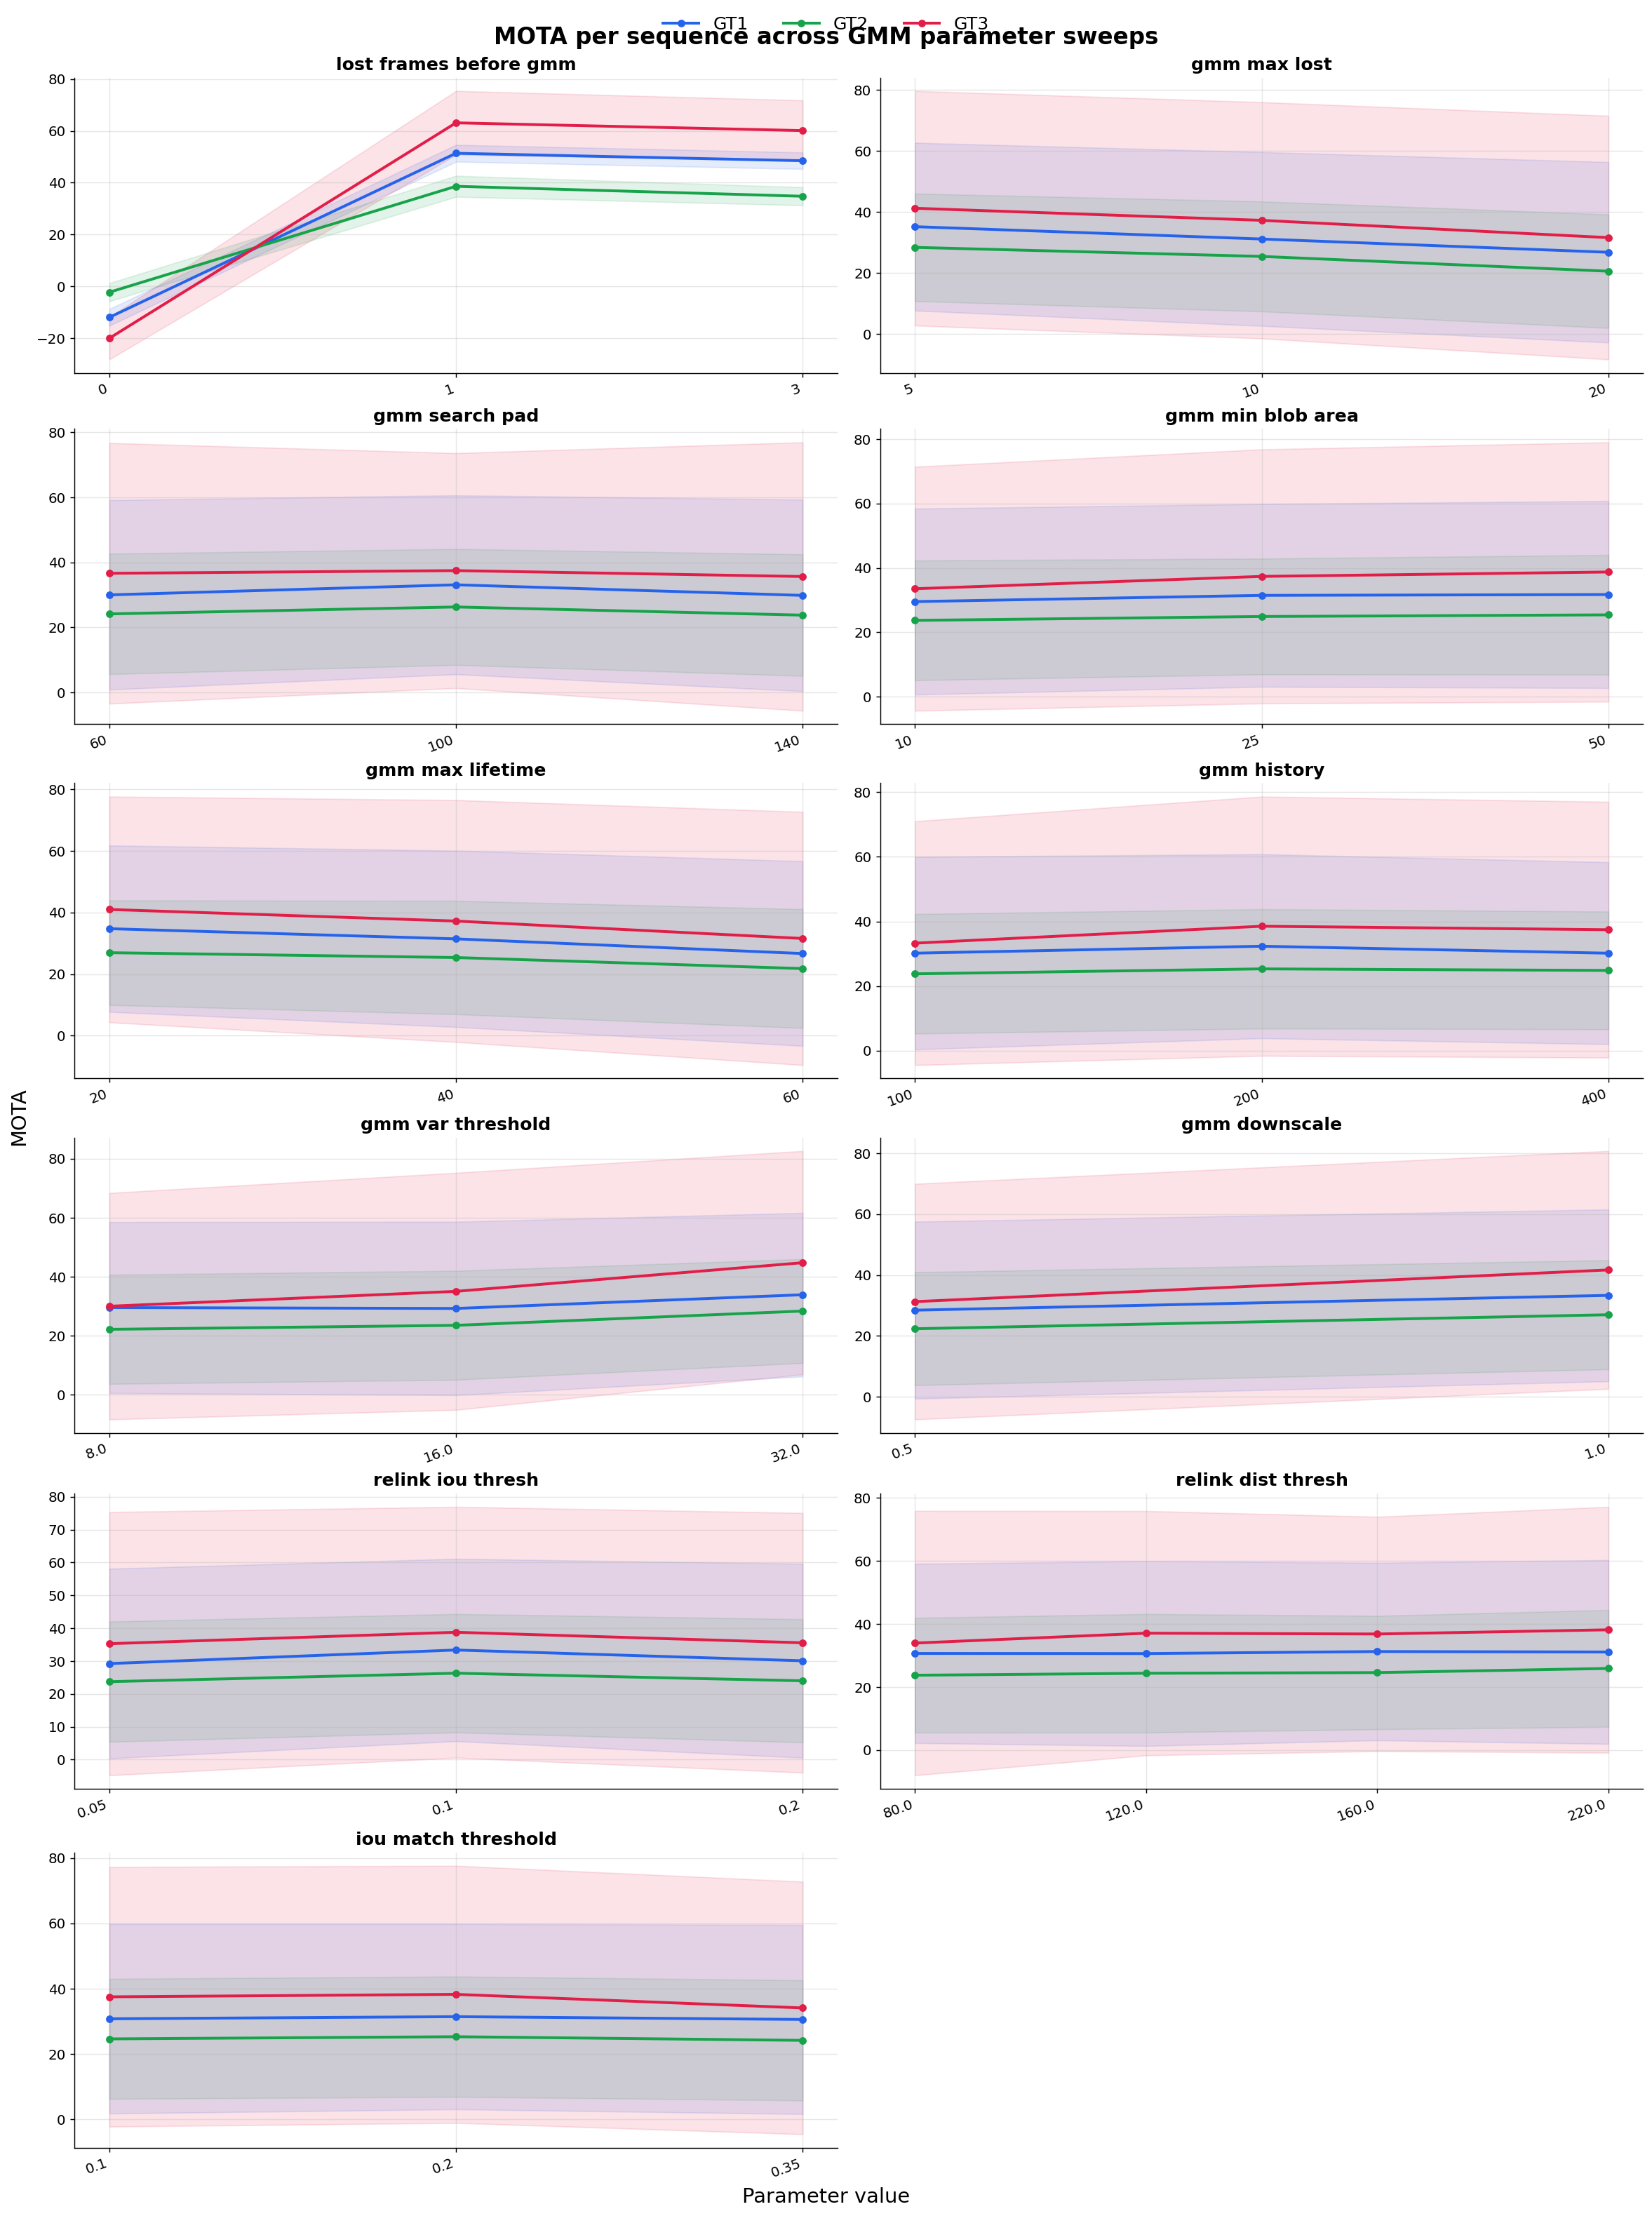

Saved -> ./output_figures/mota_per_seq_gmm_clean.png


In [23]:
# -----------------------------
# Matplotlib styling
# -----------------------------
# df_gmm already loaded in cell 9

# -----------------------------
# Parameters swept in experiments
# -----------------------------
SWEPT_PARAMS = [
    'lost_frames_before_gmm',
    'gmm_max_lost',
    'gmm_search_pad',
    'gmm_min_blob_area',
    'gmm_max_lifetime',
    'gmm_history',
    'gmm_var_threshold',
    'gmm_downscale',
    'relink_iou_thresh',
    'relink_dist_thresh',
    'iou_match_threshold'
]

# -----------------------------
# GT sequences
# -----------------------------
GT_NAMES = ['gt1', 'gt2', 'gt3']

# -----------------------------
# Plot colors
# -----------------------------
colors_gt = [
    '#2563eb',   # blue
    '#16a34a',   # green
    '#e11d48'    # red
]

# -----------------------------
# Metric to visualize
# -----------------------------
focus_metric = 'MOTA'   # HOTA / MOTA / MOTP / IDF1

# -----------------------------
# Helper function
# -----------------------------
def mean_by_param(df_gmm, param, metric):
    g = df_gmm.groupby(param)[metric]
    return g.mean(), g.std().fillna(0)

# -----------------------------
# Figure layout
# MAX 2 plots per row
# -----------------------------
ncols = 2
nrows = int(np.ceil(len(SWEPT_PARAMS) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 24),   # tall figure
    constrained_layout=True
)

axes = axes.flatten()

# -----------------------------
# Plot each parameter
# -----------------------------
for ax, param in zip(axes, SWEPT_PARAMS):

    unique_vals = sorted(df_gmm[param].unique())
    x = np.arange(len(unique_vals))

    for gt, color in zip(GT_NAMES, colors_gt):

        col = f'{gt}_{focus_metric}'

        if col not in df_gmm.columns:
            continue

        means, stds = mean_by_param(df_gmm, param, col)

        y = [means.get(v, np.nan) for v in unique_vals]
        e = [stds.get(v, 0) for v in unique_vals]

        # Main line
        ax.plot(
            x,
            y,
            marker='o',
            linewidth=2.2,
            markersize=5,
            color=color,
            label=gt.upper()
        )

        # Std shading
        ax.fill_between(
            x,
            np.array(y) - np.array(e),
            np.array(y) + np.array(e),
            alpha=0.12,
            color=color
        )

    # Titles
    ax.set_title(
        param.replace('_', ' '),
        fontsize=14,
        fontweight='bold'
    )

    # X ticks
    ax.set_xticks(x)

    ax.set_xticklabels(
        [str(v) for v in unique_vals],
        rotation=20,
        ha='right',
        fontsize=11
    )

    # Tick styling
    ax.tick_params(axis='y', labelsize=11)

# -----------------------------
# Remove unused subplots
# -----------------------------
for i in range(len(SWEPT_PARAMS), len(axes)):
    fig.delaxes(axes[i])

# -----------------------------
# Shared labels
# -----------------------------
fig.supylabel(
    focus_metric,
    fontsize=16
)

fig.supxlabel(
    'Parameter value',
    fontsize=16
)

# -----------------------------
# Global legend
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, 1.01)
)

# -----------------------------
# Figure title
# -----------------------------
fig.suptitle(
    f'{focus_metric} per sequence across GMM parameter sweeps',
    fontsize=18,
    fontweight='bold'
)

# -----------------------------
# Save figure
# -----------------------------
output_name = f'./output_figures/{focus_metric.lower()}_per_seq_gmm_clean.png'

plt.savefig(
    output_name,
    dpi=400,
    bbox_inches='tight'
)

plt.show()

print(f'Saved -> {output_name}')

## 13 · Multi-run model comparison — setup  (`./csv/models_csv/*.csv`)

In [25]:
# ── CONFIG ──────────────────────────────────────────────────────────────
# Edit CSV_FILES to point at your four files.
# Uses glob by default; override with an explicit list if preferred.

CSV_FILES = sorted(Path('./csv/models_csv').glob('*.csv'))
# CSV_FILES = [Path('run_a.csv'), Path('run_b.csv'), ...]  # explicit

if not CSV_FILES:
    raise FileNotFoundError('No CSV files found. Check CSV_FILES in the cell above.')

print(f'Found {len(CSV_FILES)} file(s):')
for f in CSV_FILES:
    print(' ', f)


def load_df(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # derived averages (recompute in case missing)
    df['avg_HOTA'] = df[['gt1_HOTA','gt2_HOTA','gt3_HOTA']].mean(axis=1)
    df['avg_MOTA'] = df[['gt1_MOTA','gt2_MOTA','gt3_MOTA']].mean(axis=1)
    df['avg_IDF1'] = df[['gt1_IDF1','gt2_IDF1','gt3_IDF1']].mean(axis=1)
    df['avg_vad']  = df[['gt1_vec_angle_diff','gt2_vec_angle_diff','gt3_vec_angle_diff']].mean(axis=1)
    return df

datasets = {p.stem: load_df(p) for p in CSV_FILES}
print('Loaded:', list(datasets.keys()))


Found 4 file(s):
  csv\models_csv\train11.csv
  csv\models_csv\train15.csv
  csv\models_csv\train2.csv
  csv\models_csv\train3.csv
Loaded: ['train11', 'train15', 'train2', 'train3']


## 14 · Best-trial comparison across runs

Best trial per run:


,avg_HOTA,avg_MOTA,avg_IDF1,conf_threshold,trial
run,,,,,
train11,72.686667,50.283333,70.203333,0.05,6
train15,55.073333,11.166667,50.033333,0.4,3
train2,74.88,52.106667,73.056667,0.05,6
train3,72.273333,47.696667,69.9,0.05,6


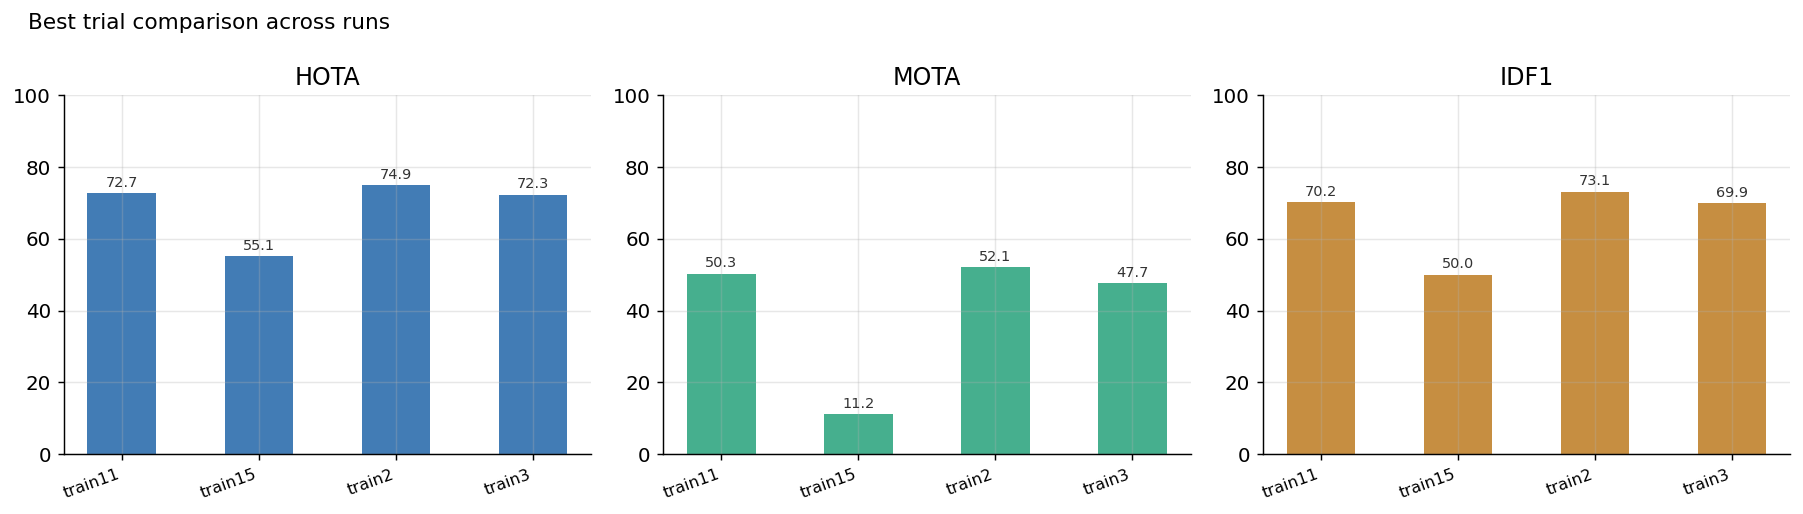

Saved → output_figures\combined_best_comparison.png


In [26]:
# ── COMBINED: best-trial comparison across all files ────────────────────
def best_row(df):
    valid = df[df['avg_HOTA'] > 0]
    return valid.loc[valid['avg_HOTA'].idxmax()] if len(valid) else df.iloc[0]

summary = pd.DataFrame({
    name: best_row(df)[['avg_HOTA','avg_MOTA','avg_IDF1','conf_threshold','trial']]
    for name, df in datasets.items()
}).T
summary.index.name = 'run'
print('Best trial per run:')
display(summary)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Best trial comparison across runs', fontsize=12, x=0.02, ha='left')

names = list(summary.index)
xn = np.arange(len(names))
metrics = [('avg_HOTA', 'HOTA', BLUE), ('avg_MOTA', 'MOTA', TEAL), ('avg_IDF1', 'IDF1', AMBER)]

for ax, (col, label, color) in zip(axes, metrics):
    vals = summary[col].astype(float)
    bars = ax.bar(xn, vals, color=color, alpha=0.82, width=0.5)
    ax.set_xticks(xn); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_title(label); ax.set_ylim(0, 100)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}',
                ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
out = OUT_DIR / 'combined_best_comparison.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved → {out}')

## 15 · avg HOTA curves — all runs

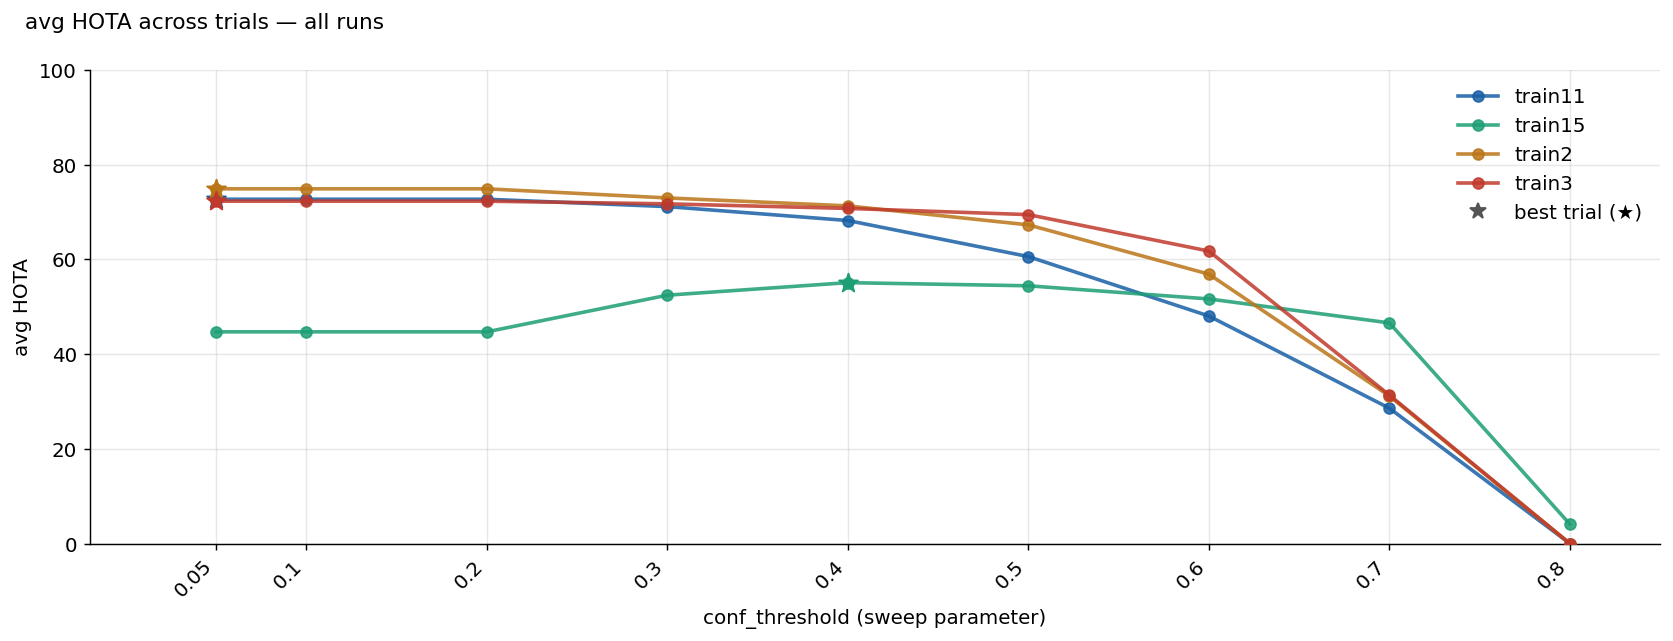

Saved → output_figures\combined_hota_curves.png


In [27]:
# ── COMBINED: avg_HOTA curves for all runs on one axes ──────────────────
palette = [BLUE, TEAL, AMBER, RED, GRAY]

all_confs = sorted(set(
    round(c, 4)
    for df in datasets.values()
    for c in df['conf_threshold']
))

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('avg HOTA across trials — all runs', x=0.02, ha='left', fontsize=12)

for (name, df), color in zip(datasets.items(), palette):
    df_s = df.sort_values('conf_threshold').reset_index(drop=True)
    ax.plot(df_s['conf_threshold'], df_s['avg_HOTA'],
            marker='o', lw=2, color=color, label=name, alpha=0.85, zorder=3)

    best = df_s.loc[df_s['avg_HOTA'].idxmax()]
    ax.scatter(best['conf_threshold'], best['avg_HOTA'],
               s=120, color=color, marker='*', zorder=5)

ax.set_xlabel('conf_threshold (sweep parameter)')
ax.set_ylabel('avg HOTA')
ax.set_ylim(0, 100)
ax.set_xlim(-0.02, max(all_confs) + 0.05)
ax.set_xticks(all_confs)
ax.set_xticklabels([str(c) for c in all_confs], rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], marker='*', color='#555', linestyle='none',
                       markersize=9, label='best trial (★)'))
ax.legend(handles=handles, loc='upper right', framealpha=0)

plt.tight_layout()
out = OUT_DIR / 'combined_hota_curves.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved → {out}')

## 16 · Tracker comparison setup  (`bytetrack.csv`, `botsort.csv`)

In [28]:
CSV_BYTETRACK = './csv/bytetrack.csv'
CSV_BOTSORT   = './csv/botsort.csv'

df_byte = pd.read_csv(CSV_BYTETRACK)
df_bot  = pd.read_csv(CSV_BOTSORT)

print(f'ByteTrack: {len(df_byte)} rows')
print(df_byte[['trial','imgsz','track_high_thresh','avg_HOTA','avg_MOTA','avg_IDF1']].head(5))
print(f'\nBotSort: {len(df_bot)} rows')
print(df_bot[['trial','imgsz','track_high_thresh','avg_HOTA','avg_MOTA','avg_IDF1']].head(5))



SWEPT_PARAMS = [
    'imgsz', 'track_high_thresh', 'track_low_thresh', 'new_track_thresh'
]

METRICS = {
    'avg_HOTA': ('HOTA', '#2563eb'),
    'avg_MOTA': ('MOTA', '#16a34a'),
    'avg_IDF1': ('IDF1', '#d97706'),
}

GT_NAMES  = ['gt1', 'gt2', 'gt3']
GT_COLORS = ['#2563eb', '#16a34a', '#e11d48']

TRACKERS = [
    {'name': 'ByteTrack', 'df': df_byte},
    {'name': 'BotSort',   'df': df_bot},
]


def mean_by_param(df, param, metric):
    g = df.groupby(param)[metric]
    return g.mean(), g.std().fillna(0)


def param_x_vals(param):
    return sorted(set(
        v for t in TRACKERS for v in t['df'][param].unique()
        if param in t['df'].columns
    ))


n_params = len(SWEPT_PARAMS)
print('Configuration ready.')

ByteTrack: 210 rows
   trial  imgsz  track_high_thresh  avg_HOTA  avg_MOTA  avg_IDF1
0    142   1280                0.1     70.95     40.97     68.48
1    147   1280                0.1     70.95     40.97     68.48
2    141   1280                0.1     70.58     40.09     68.09
3    146   1280                0.1     70.58     40.09     68.09
4    143   1280                0.1     70.57     39.55     67.97

BotSort: 1890 rows
   trial  imgsz  track_high_thresh  avg_HOTA  avg_MOTA  avg_IDF1
0   1270   1280                0.1     71.72      42.1     69.36
1   1271   1280                0.1     71.72      42.1     69.36
2   1272   1280                0.1     71.72      42.1     69.36
3   1273   1280                0.1     71.72      42.1     69.36
4   1274   1280                0.1     71.72      42.1     69.36
Configuration ready.


## 17 · Tracking metrics vs swept parameters (avg metrics)

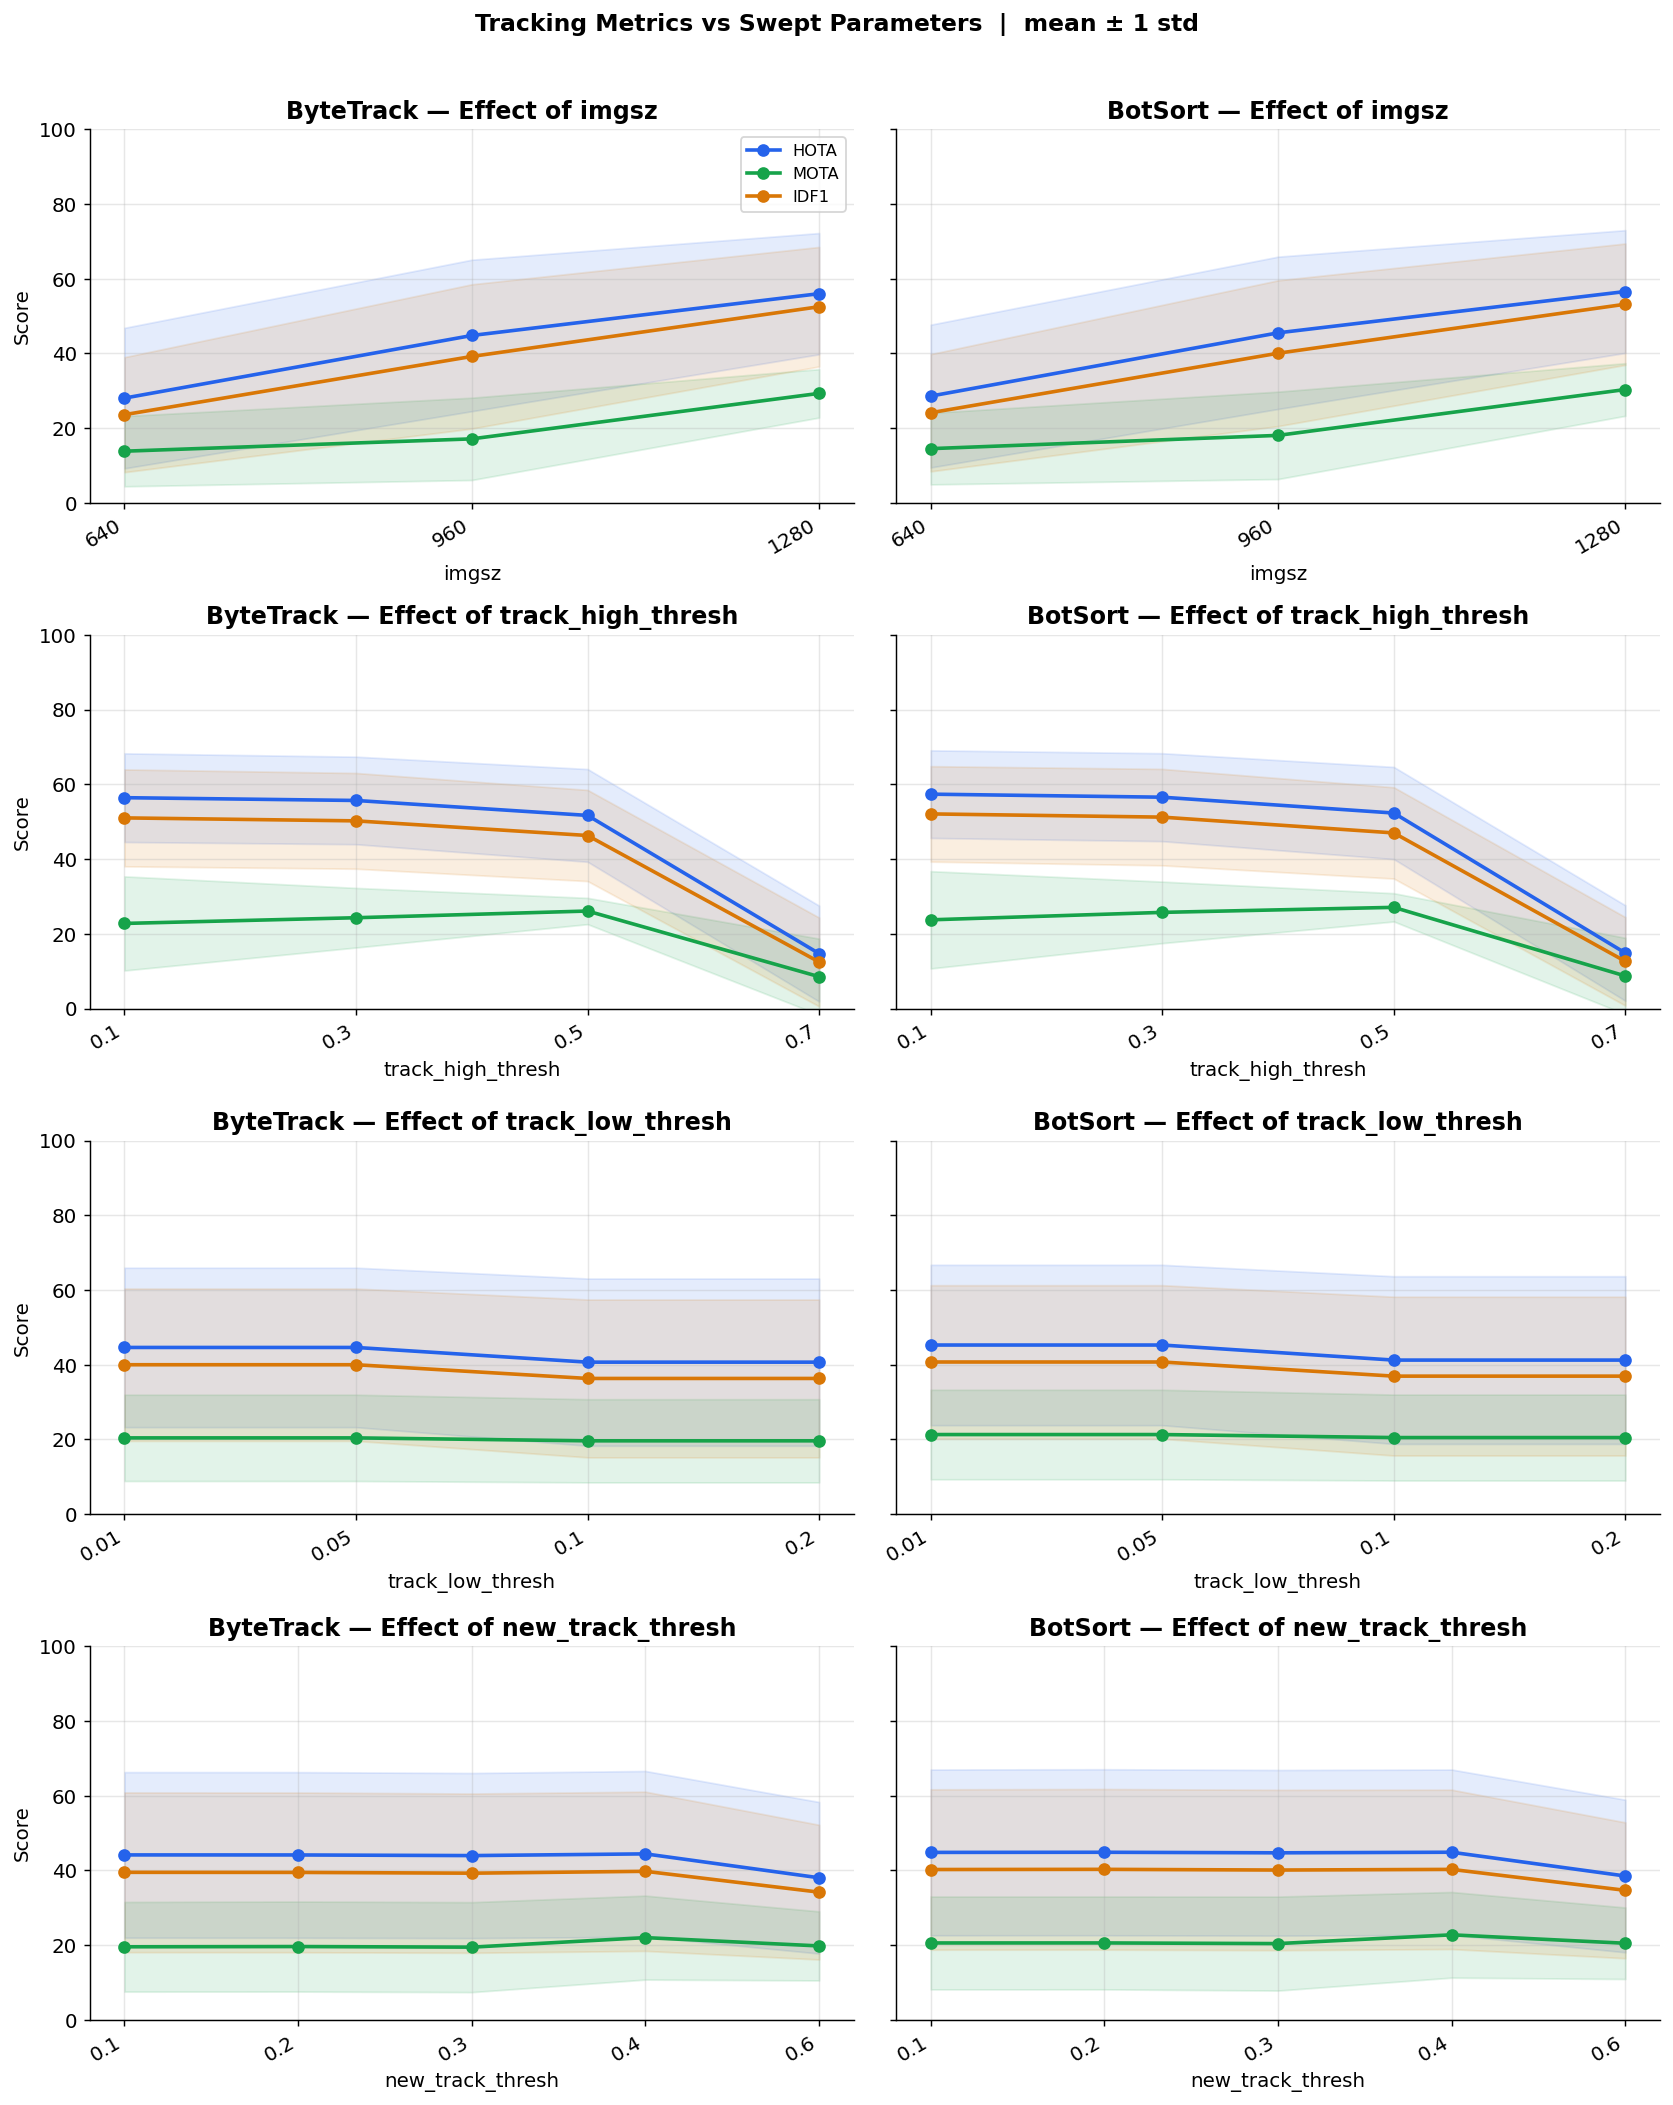

Saved → metrics_vs_params_sidebyside.png


In [30]:
fig, axes = plt.subplots(n_params, 2,
                          figsize=(13, 4 * n_params),
                          sharey='row')

for row, param in enumerate(SWEPT_PARAMS):
    all_vals = param_x_vals(param)
    x = np.arange(len(all_vals))

    for col_idx, tracker in enumerate(TRACKERS):
        ax   = axes[row][col_idx]
        df_t = tracker['df']

        for metric, (label, color) in METRICS.items():
            if param not in df_t.columns or metric not in df_t.columns:
                continue
            means, stds = mean_by_param(df_t, param, metric)
            y = np.array([means.get(v, np.nan) for v in all_vals])
            e = np.array([stds.get(v, 0)       for v in all_vals])
            ax.plot(x, y, marker='o', color=color, lw=2, label=label)
            ax.fill_between(x, y - e, y + e, color=color, alpha=0.12)

        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in all_vals], rotation=30, ha='right')
        ax.set_xlabel(param)
        ax.set_ylim(0, 100)
        ax.set_title(f'{tracker["name"]} — Effect of {param}', fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Score')
        if row == 0 and col_idx == 0:
            ax.legend(fontsize=9)

fig.suptitle('Tracking Metrics vs Swept Parameters  |  mean ± 1 std',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./output_figures/metrics_vs_params_sidebyside.png', bbox_inches='tight')
plt.show()
print('Saved → metrics_vs_params_sidebyside.png')

## 18 · Per-sequence metric lines vs swept parameters

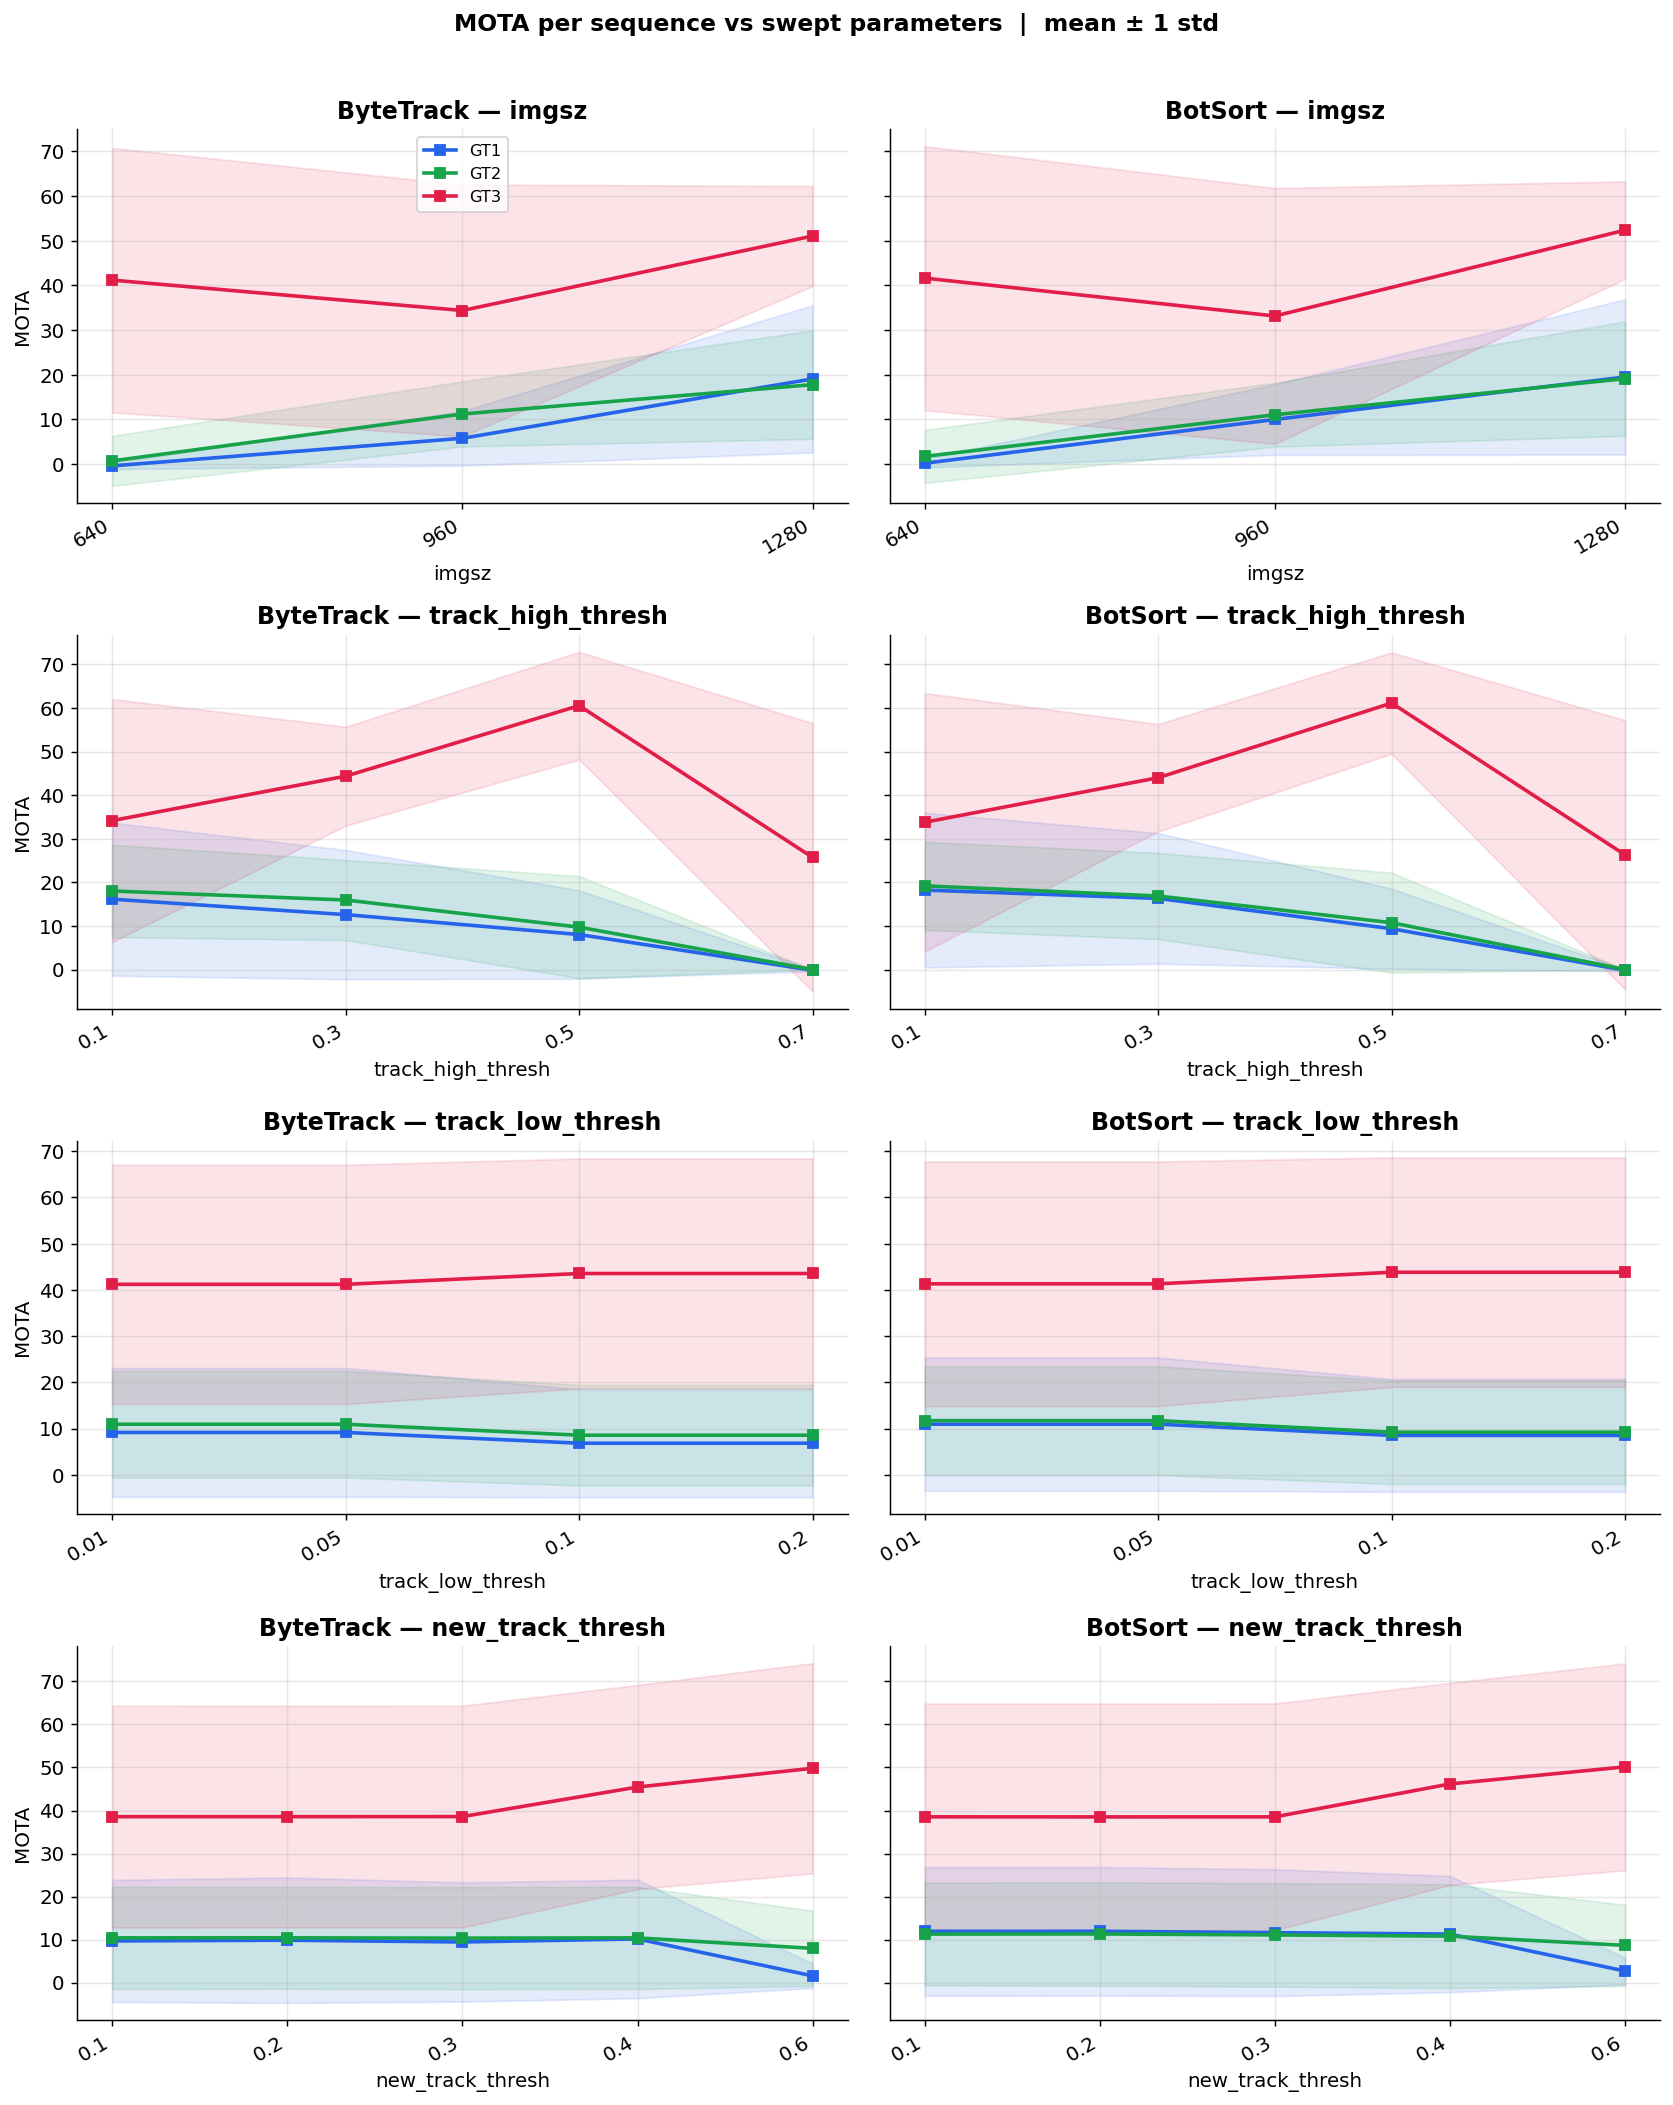

Saved → ./output_figures/mota_per_seq_sidebyside.png


In [31]:
focus_metric = 'MOTA'   # ← HOTA | MOTA | MOTP | IDF1

fig, axes = plt.subplots(n_params, 2,
                          figsize=(13, 4 * n_params),
                          sharey='row')

for row, param in enumerate(SWEPT_PARAMS):
    all_vals = param_x_vals(param)
    x = np.arange(len(all_vals))

    for col_idx, tracker in enumerate(TRACKERS):
        ax   = axes[row][col_idx]
        df_t = tracker['df']
        if param not in df_t.columns:
            continue

        for gt, color in zip(GT_NAMES, GT_COLORS):
            col = f'{gt}_{focus_metric}'
            if col not in df_t.columns:
                continue
            means, stds = mean_by_param(df_t, param, col)
            y = np.array([means.get(v, np.nan) for v in all_vals])
            e = np.array([stds.get(v, 0)       for v in all_vals])
            ax.plot(x, y, marker='s', color=color, lw=2, label=gt.upper())
            ax.fill_between(x, y - e, y + e, color=color, alpha=0.12)

        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in all_vals], rotation=30, ha='right')
        ax.set_xlabel(param)
        ax.set_title(f'{tracker["name"]} — {param}', fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(focus_metric)
        if row == 0 and col_idx == 0:
            ax.legend(fontsize=9)

fig.suptitle(f'{focus_metric} per sequence vs swept parameters  |  mean ± 1 std',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fname = f'./output_figures/{focus_metric.lower()}_per_seq_sidebyside.png'
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')

## 19 · Heatmap — side-by-side tracker comparison

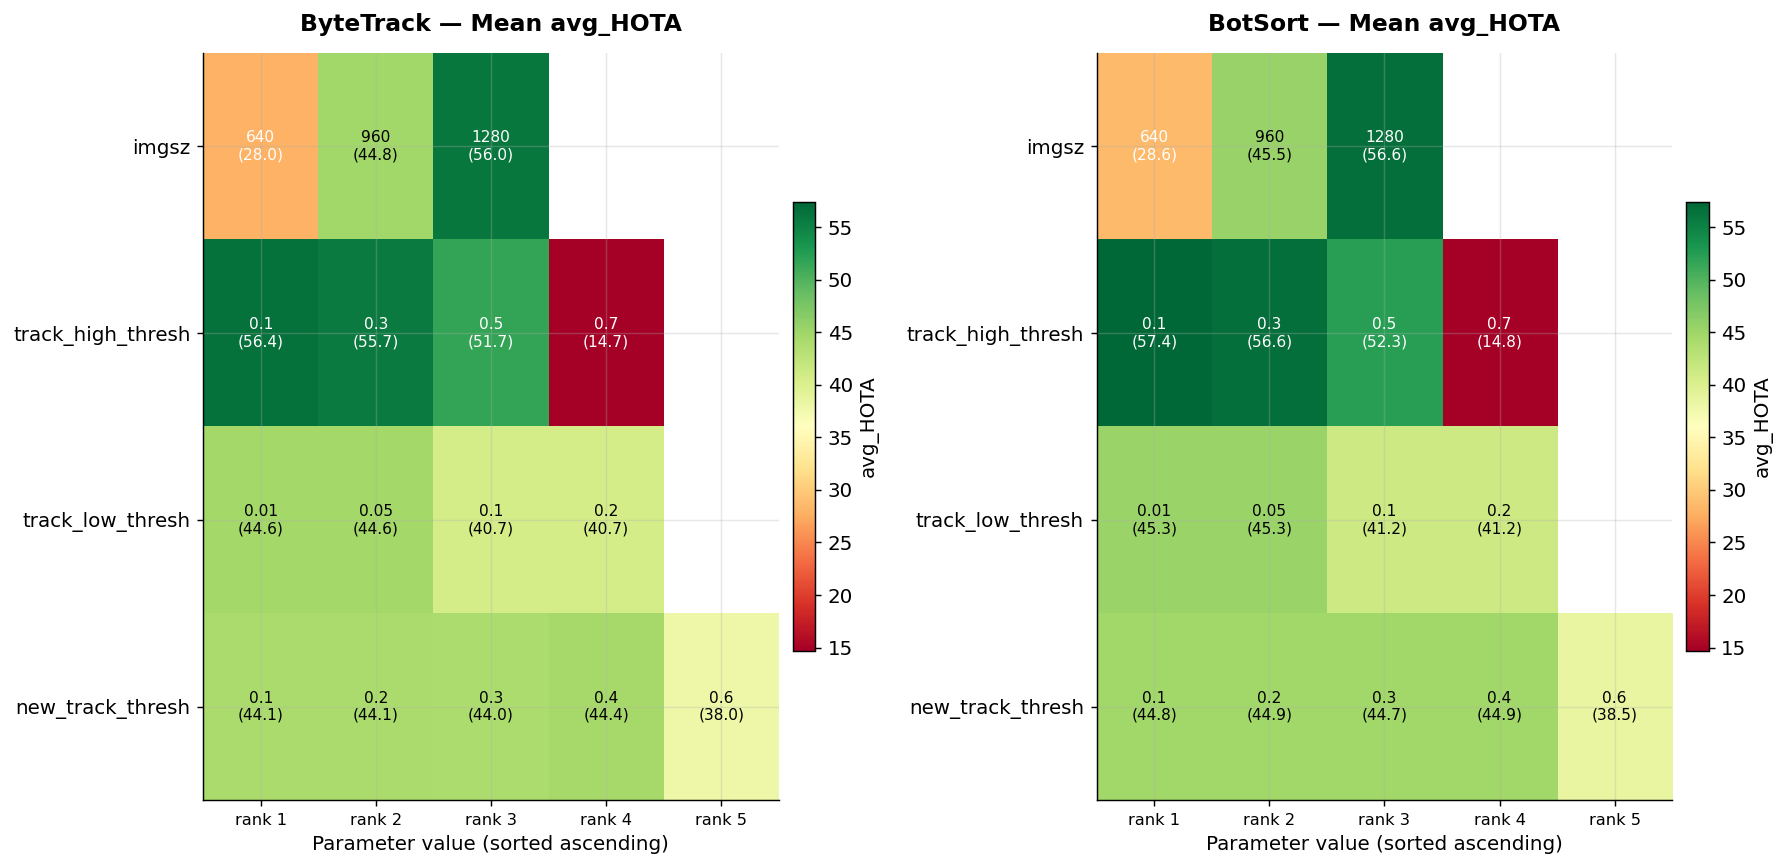

Saved → heatmap_sidebyside.png


In [ ]:
heat_metric = 'avg_HOTA'   # ← avg_MOTA | avg_IDF1

matrices = []
for tracker in TRACKERS:
    df_t   = tracker['df']
    n_cols = max(df_t[p].nunique() for p in SWEPT_PARAMS if p in df_t.columns)
    matrix = np.full((n_params, n_cols), np.nan)
    for i, param in enumerate(SWEPT_PARAMS):
        if param not in df_t.columns:
            continue
        means = df_t.groupby(param)[heat_metric].mean()
        for j, v in enumerate(sorted(df_t[param].unique())):
            matrix[i, j] = means.get(v, np.nan)
    matrices.append(matrix)

vmin     = min(np.nanmin(m) for m in matrices)
vmax     = max(np.nanmax(m) for m in matrices)
max_cols = max(m.shape[1] for m in matrices)

fig, axes = plt.subplots(1, 2, figsize=(max_cols * 2.8, n_params * 1.2 + 2))

for ax, tracker, matrix in zip(axes, TRACKERS, matrices):
    im   = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    df_t = tracker['df']
    for i, param in enumerate(SWEPT_PARAMS):
        if param not in df_t.columns:
            continue
        for j, v in enumerate(sorted(df_t[param].unique())):
            if not np.isnan(matrix[i, j]):
                nv = (matrix[i, j] - vmin) / (vmax - vmin + 1e-9)
                tc = 'black' if 0.35 < nv < 0.85 else 'white'
                ax.text(j, i, f'{v}\n({matrix[i,j]:.1f})',
                        ha='center', va='center', fontsize=8.5, color=tc)
    ax.set_yticks(range(n_params))
    ax.set_yticklabels(SWEPT_PARAMS, fontsize=11)
    ax.set_xticks(range(max_cols))
    ax.set_xticklabels([f'rank {i+1}' for i in range(max_cols)], fontsize=9)
    ax.set_xlabel('Parameter value (sorted ascending)', fontsize=11)
    ax.set_title(f'{tracker["name"]} — Mean {heat_metric}',
                 fontsize=13, fontweight='bold', pad=12)
    plt.colorbar(im, ax=ax, label=heat_metric, shrink=0.6, pad=0.02)

plt.tight_layout()
plt.savefig('./output_figures/heatmap_sidebyside.png', bbox_inches='tight')
plt.show()
print('Saved → heatmap_sidebyside.png')

## 20 · imgsz effect on elapsed time & score

In [ ]:
from matplotlib.cm import get_cmap


all_imgsz = sorted(set(
    v for t in TRACKERS for v in t['df']['imgsz'].unique()
))
n_sizes = len(all_imgsz)
cmap    = get_cmap('viridis')
all_imgsz_flat = np.concatenate([t['df']['imgsz'].values for t in TRACKERS])
norm = plt.Normalize(all_imgsz_flat.min(), all_imgsz_flat.max())
metric_markers = {'avg_HOTA': 'o', 'avg_MOTA': '^'}
metric_labels  = {'avg_HOTA': 'HOTA', 'avg_MOTA': 'MOTA'}

# 2 rows × 2 cols: top = box plots, bottom = scatter
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col_idx, tracker in enumerate(TRACKERS):
    df_t = tracker['df']

    # --- Box plot (top row) ---
    ax_box = axes[0][col_idx]
    data   = [df_t[df_t['imgsz'] == v]['elapsed_s'].values for v in all_imgsz]
    bp = ax_box.boxplot(data, patch_artist=True, widths=0.5)
    blues = get_cmap('Blues')(np.linspace(0.4, 0.85, n_sizes))
    for patch, c in zip(bp['boxes'], blues):
        patch.set_facecolor(c)
    ax_box.set_xticks(range(1, n_sizes + 1))
    ax_box.set_xticklabels(all_imgsz)
    ax_box.set_xlabel('imgsz')
    ax_box.set_ylabel('elapsed_s')
    ax_box.set_title(f'{tracker["name"]} — Elapsed time per image size',
                     fontweight='bold')

    # --- Scatter plot (bottom row) ---
    ax_sc = axes[1][col_idx]
    sc = None
    for col, mk in metric_markers.items():
        if col not in df_t.columns:
            continue
        sc = ax_sc.scatter(
            df_t['elapsed_s'], df_t[col],
            c=df_t['imgsz'], cmap=cmap, norm=norm,
            s=60, alpha=0.8, marker=mk,
            label=metric_labels[col]
        )
    if sc is not None:
        plt.colorbar(sc, ax=ax_sc, label='imgsz')
    ax_sc.set_xlabel('elapsed_s')
    ax_sc.set_ylabel('Score')
    ax_sc.set_title(f'{tracker["name"]} — HOTA & MOTA vs elapsed time',
                    fontweight='bold')
    ax_sc.legend(fontsize=9)

plt.tight_layout()
plt.savefig('imgsz_vs_time_sidebyside.png', bbox_inches='tight')
plt.show()
print('Saved → imgsz_vs_time_sidebyside.png')